In [3]:
pip install pyreadr

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 323.7/323.7 kB 2.9 MB/s eta 0:00:001.8 MB/s eta 0:00:01
Note: you may need to restart the kernel to use updated packages.


In [3]:
pip install lifelines

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 409.1/409.1 kB 2.6 MB/s eta 0:00:000:00:010:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.5/51.5 kB 716.3 kB/s eta 0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 117.3/117.3 kB 13.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 447.0/447.0 kB 10.0 MB/s eta 0:00:000:00:01
  Created wheel for autograd-gamma: filename=autograd_gamma-0.5.0-py3-none-any.whl size=4030 sha256=c7e2d8b5955953f11c66fbfc61154f9da261a5afc86f9df0e1f8cad6c6330b52
  Stored in directory: /Users/vaibhavchhabra/Library/Caches/pip/wheels/50/37/21/0a719b9d89c635e89ff24bd93b862882ad675279552013b2fb
Successfully built autograd-gamma
Note: you may need to restart the kernel to use updated packages.


In [5]:
import pandas as pd
import numpy as np
import pyreadr
import matplotlib.pyplot as plt
import seaborn as sns
from lifelines import CoxPHFitter
from sklearn.metrics import roc_auc_score, roc_curve
import os

pd.set_option('display.max_columns', 50)
pd.set_option('display.width', 200)

print("Ready.")

Ready.


In [7]:
file_path = "2019Q1.csv"

In [9]:
sample = pd.read_csv(
    file_path,
    sep="|",
    header=None,
    nrows=5,
    low_memory=False
)

print(f"Number of columns: {sample.shape[1]}")
print(f"\nFirst 5 rows:")
sample

Number of columns: 110

First 5 rows:


,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,...,85,86,87,88,89,90,91,92,93,94,95,96,97,98,99,100,101,102,103,104,105,106,107,108,109
0,NaN,100000913397,12019,C,"Jpmorgan Chase Bank, National Association",Other,NaN,5.875,5.875,324000.0,NaN,0.0,360,92018,112018,3,357,357,102048,80,80,2,49,692,665,...,A,N,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,N,NaN,NaN,NaN,NaN,NaN,7,NaN
1,NaN,100000913397,22019,C,"Jpmorgan Chase Bank, National Association",Other,NaN,5.875,5.875,324000.0,NaN,0.0,360,92018,112018,4,356,356,102048,80,80,2,49,692,665,...,A,N,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,N,NaN,NaN,NaN,NaN,NaN,7,NaN
2,NaN,100000913397,32019,C,"Jpmorgan Chase Bank, National Association",Other,NaN,5.875,5.875,324000.0,NaN,0.0,360,92018,112018,5,355,355,102048,80,80,2,49,692,665,...,A,N,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,N,NaN,NaN,NaN,NaN,NaN,7,NaN
3,NaN,100000913397,42019,C,"Jpmorgan Chase Bank, National Association",Other,NaN,5.875,5.875,324000.0,NaN,0.0,360,92018,112018,6,354,354,102048,80,80,2,49,692,665,...,A,N,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,N,NaN,NaN,NaN,NaN,NaN,7,NaN
4,NaN,100000913397,52019,C,"Jpmorgan Chase Bank, National Association",Other,NaN,5.875,5.875,324000.0,NaN,0.0,360,92018,112018,7,353,353,102048,80,80,2,49,692,665,...,A,N,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,N,NaN,NaN,NaN,NaN,NaN,7,NaN


In [11]:
import os
size_gb = os.path.getsize(file_path) / (1024**3)
print(f"File size: {size_gb:.2f} GB")

with open(file_path, 'r') as f:
    total_rows = sum(1 for _ in f)
print(f"Total rows: {total_rows:,}")

File size: 3.12 GB
Total rows: 11,389,012


In [13]:
# Print first non-null value at each column position
print("Col# | First non-null value")
print("-" * 60)
for i in range(sample.shape[1]):
    non_null = sample.iloc[:, i].dropna()
    val = non_null.iloc[0] if len(non_null) > 0 else "ALL NaN (in first 5 rows)"
    # Truncate long strings for readability
    val_str = str(val)[:50]
    print(f"{i:3d}  | {val_str}")

Col# | First non-null value
------------------------------------------------------------
  0  | ALL NaN (in first 5 rows)
  1  | 100000913397
  2  | 12019
  3  | C
  4  | Jpmorgan Chase Bank, National Association
  5  | Other
  6  | ALL NaN (in first 5 rows)
  7  | 5.875
  8  | 5.875
  9  | 324000.0
 10  | ALL NaN (in first 5 rows)
 11  | 0.0
 12  | 360
 13  | 92018
 14  | 112018
 15  | 3
 16  | 357
 17  | 357
 18  | 102048
 19  | 80
 20  | 80
 21  | 2
 22  | 49
 23  | 692
 24  | 665
 25  | N
 26  | C
 27  | PU
 28  | 1
 29  | P
 30  | CA
 31  | 40140
 32  | 925
 33  | ALL NaN (in first 5 rows)
 34  | FRM
 35  | N
 36  | N
 37  | ALL NaN (in first 5 rows)
 38  | ALL NaN (in first 5 rows)
 39  | 0
 40  | ALL NaN (in first 5 rows)
 41  | N
 42  | ALL NaN (in first 5 rows)
 43  | ALL NaN (in first 5 rows)
 44  | ALL NaN (in first 5 rows)
 45  | ALL NaN (in first 5 rows)
 46  | ALL NaN (in first 5 rows)
 47  | ALL NaN (in first 5 rows)
 48  | ALL NaN (in first 5 rows)
 49  | ALL NaN (in fi

In [19]:
# Verify column positions by reading first 10 rows with named columns
cols_to_check = {
    1: 'loan_id',
    2: 'rpt_period',
    7: 'orig_rate',
    9: 'orig_upb',
    11: 'current_upb',
    13: 'orig_date',
    15: 'loan_age',
    19: 'oltv',
    22: 'dti',
    23: 'fico',
    29: 'occ_status',
    30: 'state',
    39: 'dlq_status',
    41: 'mod_flag'
}

check = pd.read_csv(
    file_path,
    sep="|",
    header=None,
    usecols=list(cols_to_check.keys()),
    nrows=10,
    low_memory=False
)
check.columns = [cols_to_check[c] for c in sorted(cols_to_check.keys())]
check

,loan_id,rpt_period,orig_rate,orig_upb,current_upb,orig_date,loan_age,oltv,dti,fico,occ_status,state,dlq_status,mod_flag
0,100000913397,12019,5.875,324000.0,0.00,92018,3,80,49,692,P,CA,0,N
1,100000913397,22019,5.875,324000.0,0.00,92018,4,80,49,692,P,CA,0,N
2,100000913397,32019,5.875,324000.0,0.00,92018,5,80,49,692,P,CA,0,N
3,100000913397,42019,5.875,324000.0,0.00,92018,6,80,49,692,P,CA,0,N
4,100000913397,52019,5.875,324000.0,0.00,92018,7,80,49,692,P,CA,0,N
5,100000913397,62019,5.875,324000.0,0.00,92018,8,80,49,692,P,CA,0,N
6,100000913397,72019,5.875,324000.0,320968.13,92018,9,80,49,692,P,CA,0,N
7,100000913397,82019,5.875,324000.0,320622.96,92018,10,80,49,692,P,CA,0,N
8,100000913397,92019,5.875,324000.0,320276.10,92018,11,80,49,692,P,CA,0,N
9,100000913397,102019,5.875,324000.0,319927.54,92018,12,80,49,692,P,CA,0,N


In [21]:
!pip install pyarrow

In [23]:
# Run this in a new cell first to clear any leftover memory
import gc
try:
    del chunks
    del df
except NameError:
    pass
gc.collect()
print("Memory cleared.")

Memory cleared.


In [25]:
import time
import gc

cols_to_load = {
    1:  'loan_id',
    2:  'rpt_period',
    7:  'orig_rate',
    9:  'orig_upb',
    11: 'current_upb',
    13: 'orig_date',
    15: 'loan_age',
    19: 'oltv',
    22: 'dti',
    23: 'fico',
    27: 'prop_type',
    29: 'occ_status',
    30: 'state',
    31: 'msa',
    39: 'dlq_status',
    41: 'mod_flag',
    43: 'zero_bal_code',
}

col_positions = sorted(cols_to_load.keys())
col_names = [cols_to_load[p] for p in col_positions]

dtypes = {
    'loan_id':       'int64',      # keep as int, loan IDs are never missing
    'rpt_period':    'float32',    # changed from int32
    'orig_rate':     'float32',
    'orig_upb':      'float32',
    'current_upb':   'float32',
    'orig_date':     'float32',    # changed from int32
    'loan_age':      'float32',    # changed from int16 (was the culprit)
    'oltv':          'float32',
    'dti':           'float32',
    'fico':          'float32',
    'prop_type':     'category',
    'occ_status':    'category',
    'state':         'category',
    'msa':           'float32',
    'dlq_status':    'string',
    'mod_flag':      'category',
    'zero_bal_code': 'float32',
}

chunk_size = 300_000  # smaller chunks for 8GB machine
chunks = []
start = time.time()
total_rows = 0

print("Loading 2019Q1 in chunks. ~15 min. Watch Activity Monitor.")
print("-" * 60)

for i, chunk in enumerate(pd.read_csv(
    file_path,
    sep="|",
    header=None,
    usecols=col_positions,
    names=col_names,
    dtype=dtypes,
    chunksize=chunk_size,
    low_memory=False
)):
    chunks.append(chunk)
    total_rows += len(chunk)
    elapsed = time.time() - start
    print(f"Chunk {i+1:2d} | rows: {total_rows:>10,} | time: {elapsed:>4.0f}s")

print("-" * 60)
print("Concatenating chunks...")
df = pd.concat(chunks, ignore_index=True)
del chunks
gc.collect()

print(f"\nShape: {df.shape}")
print(f"Memory: {df.memory_usage(deep=True).sum() / 1024**2:.0f} MB")

# Save to Parquet so we never have to do this slow load again
print("\nSaving to Parquet...")
df.to_parquet("2019Q1_slim.parquet", compression="snappy")
print(f"Parquet file saved. Total time: {(time.time() - start)/60:.1f} min")

df.head()

Loading 2019Q1 in chunks. ~15 min. Watch Activity Monitor.
------------------------------------------------------------
Chunk  1 | rows:    300,000 | time:    1s
Chunk  2 | rows:    600,000 | time:    1s
Chunk  3 | rows:    900,000 | time:    2s
Chunk  4 | rows:  1,200,000 | time:    2s
Chunk  5 | rows:  1,500,000 | time:    3s
Chunk  6 | rows:  1,800,000 | time:    4s
Chunk  7 | rows:  2,100,000 | time:    4s
Chunk  8 | rows:  2,400,000 | time:    5s
Chunk  9 | rows:  2,700,000 | time:    5s
Chunk 10 | rows:  3,000,000 | time:    6s
Chunk 11 | rows:  3,300,000 | time:    6s
Chunk 12 | rows:  3,600,000 | time:    7s
Chunk 13 | rows:  3,900,000 | time:    8s
Chunk 14 | rows:  4,200,000 | time:    8s
Chunk 15 | rows:  4,500,000 | time:    9s
Chunk 16 | rows:  4,800,000 | time:    9s
Chunk 17 | rows:  5,100,000 | time:   10s
Chunk 18 | rows:  5,400,000 | time:   11s
Chunk 19 | rows:  5,700,000 | time:   11s
Chunk 20 | rows:  6,000,000 | time:   12s
Chunk 21 | rows:  6,300,000 | time:   12

,loan_id,rpt_period,orig_rate,orig_upb,current_upb,orig_date,loan_age,oltv,dti,fico,prop_type,occ_status,state,msa,dlq_status,mod_flag,zero_bal_code
0,100000913397,12019.0,5.875,324000.0,0.0,92018.0,3.0,80.0,49.0,692.0,PU,P,CA,40140.0,00,N,NaN
1,100000913397,22019.0,5.875,324000.0,0.0,92018.0,4.0,80.0,49.0,692.0,PU,P,CA,40140.0,00,N,NaN
2,100000913397,32019.0,5.875,324000.0,0.0,92018.0,5.0,80.0,49.0,692.0,PU,P,CA,40140.0,00,N,NaN
3,100000913397,42019.0,5.875,324000.0,0.0,92018.0,6.0,80.0,49.0,692.0,PU,P,CA,40140.0,00,N,NaN
4,100000913397,52019.0,5.875,324000.0,0.0,92018.0,7.0,80.0,49.0,692.0,PU,P,CA,40140.0,00,N,NaN


In [27]:
# First, see what zero_bal_codes exist in the data and how common each is
print("Distribution of zero_bal_code values:")
print(df['zero_bal_code'].value_counts(dropna=False))
print()

# Also look at modification flag
print("Distribution of mod_flag:")
print(df['mod_flag'].value_counts(dropna=False))
print()

# Number of unique loans
print(f"Unique loans in 2019Q1: {df['loan_id'].nunique():,}")
print(f"Total loan-months: {len(df):,}")
print(f"Avg months per loan: {len(df) / df['loan_id'].nunique():.1f}")

Distribution of zero_bal_code values:
zero_bal_code
NaN     11112433
1.0       274959
16.0         568
6.0          458
2.0          202
9.0          191
15.0         160
3.0           41
Name: count, dtype: int64

Distribution of mod_flag:
mod_flag
N      10965145
NaN      276105
Y        147762
Name: count, dtype: int64

Unique loans in 2019Q1: 341,865
Total loan-months: 11,389,012
Avg months per loan: 33.3


In [29]:
import time
start = time.time()

# Step 1: For each loan, get the terminal (last) zero_bal_code
# We use the last non-null zbc across all rows per loan
loan_terminal = df.groupby('loan_id').agg(
    last_zbc=('zero_bal_code', 'max'),       # max works because only 1 non-null per loan
    has_mod=('mod_flag', lambda x: (x == 'Y').any()),
    n_months=('loan_id', 'size')
).reset_index()

print(f"Aggregation done in {time.time()-start:.1f}s")
print(f"Loans in aggregate table: {len(loan_terminal):,}")

# Step 2: Classify each loan
def classify(row):
    zbc = row['last_zbc']
    has_mod = row['has_mod']
    
    # Default codes
    if zbc in [2, 3, 9, 15]:
        return 'default'
    # Prepaid
    elif zbc == 1:
        return 'prepaid'
    # Censored: repurchased, reperforming, or modified
    elif zbc in [6, 16]:
        return 'censored'
    elif has_mod:
        return 'censored'
    # Still active
    else:
        return 'current'

loan_terminal['status'] = loan_terminal.apply(classify, axis=1)

print(f"\nClassification done in {time.time()-start:.1f}s")
print("\nFinal loan status distribution:")
print(loan_terminal['status'].value_counts())
print()
print(loan_terminal['status'].value_counts(normalize=True).round(4) * 100)

Aggregation done in 6.1s
Loans in aggregate table: 341,865

Classification done in 6.8s

Final loan status distribution:
status
prepaid     274959
current      61888
censored      4424
default        594
Name: count, dtype: int64

status
prepaid     80.43
current     18.10
censored     1.29
default      0.17
Name: proportion, dtype: float64


In [33]:
import time
start = time.time()

# Drop the columns we're about to rebuild
df = df.drop(columns=['is_last_month', 'event_default', 'event_prepaid'], errors='ignore')

print("Rebuilding event indicators (correct logic)...")

# An event happens on the row where zero_bal_code is populated (not NaN)
# For defaults: zero_bal_code in [2, 3, 9, 15]
# For prepaids: zero_bal_code == 1
df['event_default'] = df['zero_bal_code'].isin([2, 3, 9, 15]).astype('int8')
df['event_prepaid'] = (df['zero_bal_code'] == 1).astype('int8')

print(f"  Done in {time.time()-start:.1f}s")

# The termination row has loan_age=NaN, so start/end are NaN too
# We need to fix this: set start/end on termination rows using the previous month's loan_age + 1

# Strategy: forward-fill loan_age within each loan, then recompute start/end
# Terminal row becomes: start = (max loan_age) + 1, end = (max loan_age) + 2
# This gives the event its own 1-month interval after the last observation

print("Fixing start/end on termination rows...")
# For each loan, find the max non-NaN loan_age
df['max_age'] = df.groupby('loan_id')['loan_age'].transform('max')

# Where loan_age is NaN (termination row), fill in with max_age + 1
# This tells Cox "the event happened during the month immediately after the last reporting row"
mask_term = df['loan_age'].isna()
df.loc[mask_term, 'loan_age'] = df.loc[mask_term, 'max_age'] + 1

# Recompute start/end
df['start'] = df['loan_age']
df['end']   = df['loan_age'] + 1

# Drop max_age, no longer needed
df = df.drop(columns=['max_age'])

print(f"  Done in {time.time()-start:.1f}s")

# Sanity checks
print(f"\n--- Sanity checks ---")
print(f"Total rows:            {len(df):,}")
print(f"Unique loans:          {df['loan_id'].nunique():,}")
print(f"Sum of default events: {df['event_default'].sum():,}  (expected: 594)")
print(f"Sum of prepaid events: {df['event_prepaid'].sum():,}  (expected: 274,959)")
print(f"Rows with NaN start:   {df['start'].isna().sum():,}  (should be 0)")

# Show the same defaulted loan again to verify
example_id = 102303262055
print(f"\n--- Re-check defaulted loan {example_id} (last 6 rows) ---")
cols_to_show = ['loan_age', 'start', 'end', 'current_upb', 
                'dlq_status', 'zero_bal_code', 'event_default']
print(df[df['loan_id'] == example_id][cols_to_show].tail(6).to_string(index=False))

# Also show a prepaid loan to verify that structure
prepaid_id = df[df['status'] == 'prepaid']['loan_id'].iloc[0]
print(f"\n--- Example prepaid loan {prepaid_id} (last 6 rows) ---")
cols_to_show_pp = ['loan_age', 'start', 'end', 'current_upb', 
                   'dlq_status', 'zero_bal_code', 'event_prepaid']
print(df[df['loan_id'] == prepaid_id][cols_to_show_pp].tail(6).to_string(index=False))

print(f"\nTotal time: {time.time()-start:.1f}s")
print(f"Memory: {df.memory_usage(deep=True).sum() / 1024**2:.0f} MB")

Rebuilding event indicators (correct logic)...
  Done in 1.5s
Fixing start/end on termination rows...
  Done in 2.1s

--- Sanity checks ---
Total rows:            11,389,012
Unique loans:          341,865
Sum of default events: 594  (expected: 594)
Sum of prepaid events: 274,959  (expected: 274,959)
Rows with NaN start:   0  (should be 0)

--- Re-check defaulted loan 102303262055 (last 6 rows) ---
 loan_age  start  end  current_upb dlq_status  zero_bal_code  event_default
     36.0   36.0 37.0 81386.546875         29            NaN              0
     37.0   37.0 38.0 81386.546875         30            NaN              0
     38.0   38.0 39.0 81386.546875         31            NaN              0
     39.0   39.0 40.0 81386.546875         32            NaN              0
     40.0   40.0 41.0 81386.546875         33            NaN              0
     41.0   41.0 42.0     0.000000         34            2.0              1

--- Example prepaid loan 100000913397 (last 6 rows) ---
 loan_age 

In [35]:
import time
start = time.time()

# Pre-modeling cleanup
print("Cleaning data for Cox modeling...")

# 1) Fix the first-6-months UPB blanking (Fannie blanks, filled with orig_upb)
mask_early = (df['loan_age'] <= 6) & (df['current_upb'] == 0)
df.loc[mask_early, 'current_upb'] = df.loc[mask_early, 'orig_upb']
print(f"  Filled {mask_early.sum():,} early-month UPB rows with orig_upb")

# 2) Convert dlq_status string codes to numeric 
# values are "00", "01", ..., "XX" (unknown), or NaN
# "XX" appears on termination rows - set to NaN
df['dlq_numeric'] = pd.to_numeric(df['dlq_status'], errors='coerce')
print(f"  Created dlq_numeric. XX/NaN rows: {df['dlq_numeric'].isna().sum():,}")

# 3) Drop rows where key modeling variables are missing (FICO, OLTV, DTI)
rows_before = len(df)
df = df.dropna(subset=['fico', 'oltv', 'dti']).reset_index(drop=True)
rows_after = len(df)
print(f"  Dropped {rows_before - rows_after:,} rows with missing fico/oltv/dti")
print(f"  Rows remaining: {rows_after:,}")

# 4) Final event count re-check after cleanup
print(f"\n--- After cleanup ---")
print(f"Default events: {df['event_default'].sum():,}")
print(f"Prepaid events: {df['event_prepaid'].sum():,}")
print(f"Unique loans:   {df['loan_id'].nunique():,}")

# 5) Quick look at distributions
print("\n--- FICO distribution ---")
print(df[['fico']].describe().round(1))
print("\n--- OLTV distribution ---")
print(df[['oltv']].describe().round(1))

# Save the cleaned panel to Parquet too
print("\nSaving cleaned panel to Parquet...")
df.to_parquet("2019Q1_panel.parquet", compression="snappy")
print(f"Done in {time.time()-start:.1f}s")

Cleaning data for Cox modeling...
  Filled 2,010,102 early-month UPB rows with orig_upb
  Created dlq_numeric. XX/NaN rows: 86,309
  Dropped 17,951 rows with missing fico/oltv/dti
  Rows remaining: 11,371,061

--- After cleanup ---
Default events: 592
Prepaid events: 274,635
Unique loans:   341,433

--- FICO distribution ---
             fico
count  11371061.0
mean        740.7
std          51.7
min         620.0
25%         704.0
50%         746.0
75%         782.0
max         834.0

--- OLTV distribution ---
             oltv
count  11371061.0
mean         76.7
std          18.3
min           2.0
25%          68.0
50%          80.0
75%          95.0
max          97.0

Saving cleaned panel to Parquet...
Done in 7.7s


In [37]:
import time
from lifelines import CoxPHFitter

# Sample 20% of loans (not rows — we keep whole loan histories intact)
np.random.seed(42)
sample_loans = np.random.choice(
    df['loan_id'].unique(),
    size=int(df['loan_id'].nunique() * 0.20),
    replace=False
)
df_sample = df[df['loan_id'].isin(sample_loans)].copy()
print(f"Sample: {len(df_sample):,} rows | {df_sample['loan_id'].nunique():,} loans")
print(f"Default events in sample: {df_sample['event_default'].sum():,}")
print(f"Prepaid events in sample: {df_sample['event_prepaid'].sum():,}")

# Build the modeling frame — only columns Cox needs
# For default model: prepaid is treated as censoring (competing risks)
model_df = df_sample[['start', 'end', 'event_default', 'oltv', 'fico']].copy()

# Drop any rows where start >= end (shouldn't exist, but safety)
model_df = model_df[model_df['end'] > model_df['start']].reset_index(drop=True)
print(f"Modeling frame: {len(model_df):,} rows")

# Fit Cox PH
print("\nFitting cox_v1 (oltv + fico)...")
start = time.time()

cph_v1 = CoxPHFitter()
cph_v1.fit(
    model_df,
    duration_col='end',
    event_col='event_default',
    entry_col='start',
    show_progress=True
)

elapsed = time.time() - start
print(f"\nFit done in {elapsed:.1f}s")

# Show results (same format as R's summary(cox_v1))
cph_v1.print_summary()

Sample: 2,283,094 rows | 68,286 loans
Default events in sample: 116
Prepaid events in sample: 54,715
Modeling frame: 2,283,094 rows

Fitting cox_v1 (oltv + fico)...
Iteration 1: norm_delta = 7.29e-01, step_size = 0.9500, log_lik = -1132.20464, newton_decrement = 3.49e+01, seconds_since_start = 0.4
Iteration 2: norm_delta = 1.97e-01, step_size = 0.9500, log_lik = -1095.60503, newton_decrement = 1.62e+00, seconds_since_start = 0.7
Iteration 3: norm_delta = 3.10e-02, step_size = 0.9500, log_lik = -1093.90926, newton_decrement = 3.28e-02, seconds_since_start = 1.1
Iteration 4: norm_delta = 4.84e-04, step_size = 1.0000, log_lik = -1093.87613, newton_decrement = 7.68e-06, seconds_since_start = 1.5
Iteration 5: norm_delta = 1.17e-07, step_size = 1.0000, log_lik = -1093.87612, newton_decrement = 4.52e-13, seconds_since_start = 2.0
Convergence success after 5 iterations.

Fit done in 2.9s


<lifelines.CoxPHFitter: fitted with 2.28309e+06 total observations, 2.28298e+06 right-censored observations>
             duration col = 'end'
                event col = 'event_default'
                entry col = 'start'
      baseline estimation = breslow
   number of observations = 2.28309e+06
number of events observed = 116
   partial log-likelihood = -1093.88
         time fit was run = 2026-04-18 22:49:43 UTC

---
           coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                  
oltv       0.03      1.03      0.01            0.02            0.04                1.02                1.05
fico      -0.01      0.99      0.00           -0.02           -0.01                0.98                0.99

           cmp to     z      p  -log2(p)
covariate                               
oltv         0.00  4.55 <0.005     17.49
fico         0.00 -6.89 <0.005     37.40
---
Concordance = 0.74
Partial AIC = 2191.75
log-likelihood ratio test = 76.66 on 2 df
-log2(p) of ll-ratio test = 55.30

In [39]:
# Save the fitted model and sample results
import pickle

with open('cox_v1_sample.pkl', 'wb') as f:
    pickle.dump(cph_v1, f)

# Save sample coefficients as CSV for the eventual writeup
cph_v1.summary.to_csv('cox_v1_sample_results.csv')

print("Model and results saved.")
print("\nCoefficients for later reference:")
print(cph_v1.summary[['coef', 'exp(coef)', 'se(coef)', 'p']])

Model and results saved.

Coefficients for later reference:
              coef  exp(coef)  se(coef)             p
covariate                                            
oltv       0.03076   1.031238  0.006765  5.445937e-06
fico      -0.01349   0.986601  0.001957  5.515438e-12


In [41]:
!pip install pandas-datareader

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 109.5/109.5 kB 1.2 MB/s eta 0:00:0031m691.7 kB/s eta 0:00:01


In [43]:
import pandas_datareader.data as pdr
from datetime import datetime
import time
start = time.time()

# Fetch weekly 30-year fixed mortgage rate from FRED (Freddie Mac PMMS)
print("Fetching MORTGAGE30US from FRED...")
rates = pdr.DataReader(
    'MORTGAGE30US',
    'fred',
    start=datetime(2017, 1, 1),   # buffer before 2019 origination dates
    end=datetime(2020, 6, 30)
)
rates.columns = ['natl_rate']
print(f"Got {len(rates)} weekly rate observations")
print(rates.head(3))
print(rates.tail(3))

# Calculate 4-week moving average (rollapply width=4)
rates['natl_rate_4wk'] = rates['natl_rate'].rolling(window=4).mean()

# Keep one observation per month (last of each month, matching to.period())
rates['year'] = rates.index.year
rates['month'] = rates.index.month
monthly_rates = rates.groupby(['year', 'month']).tail(1).copy()
monthly_rates = monthly_rates[['year', 'month', 'natl_rate_4wk']].reset_index(drop=True)

# Create a merge key matching Fannie's orig_date format (MYYYY or MMYYYY as integer)
# As we see Fannie encodes Jan 2019 as 12019, Sep 2018 as 92018, etc.
monthly_rates['orig_date_key'] = (
    monthly_rates['month'].astype(str) +
    monthly_rates['year'].astype(str)
).astype(int)

print(f"\nMonthly rate table (first 10 rows):")
print(monthly_rates.head(10))

# Now merge onto our panel
print("\nMerging national rate onto loan panel...")
df = df.merge(
    monthly_rates[['orig_date_key', 'natl_rate_4wk']],
    left_on='orig_date',
    right_on='orig_date_key',
    how='left'
)
df = df.drop(columns=['orig_date_key'])

# Compute spread = loan's origination rate minus national rate at that month
df['spread'] = df['orig_rate'] - df['natl_rate_4wk']

print(f"Merge done in {time.time()-start:.1f}s")
print(f"\n--- Spread diagnostics ---")
print(f"Rows with NaN spread: {df['spread'].isna().sum():,}")
print(f"Spread distribution:")
print(df['spread'].describe().round(3))

# Save updated panel
print("\nSaving updated panel with spread...")
df.to_parquet("2019Q1_panel.parquet", compression="snappy")
print("Done.")

Fetching MORTGAGE30US from FRED...
Got 182 weekly rate observations
            natl_rate
DATE                 
2017-01-05       4.20
2017-01-12       4.12
2017-01-19       4.09
            natl_rate
DATE                 
2020-06-11       3.21
2020-06-18       3.13
2020-06-25       3.13

Monthly rate table (first 10 rows):
   year  month  natl_rate_4wk  orig_date_key
0  2017      1         4.1500          12017
1  2017      2         4.1675          22017
2  2017      3         4.2200          32017
3  2017      4         4.0450          42017
4  2017      5         4.0100          52017
5  2017      6         3.8950          62017
6  2017      7         3.9675          72017
7  2017      8         3.8675          82017
8  2017      9         3.8050          92017
9  2017     10         3.8950         102017

Merging national rate onto loan panel...
Merge done in 2.2s

--- Spread diagnostics ---
Rows with NaN spread: 98
Spread distribution:
count    1.137096e+07
mean     4.420000e-01
s

In [47]:
import time
from lifelines import CoxPHFitter

# Rebuild the sample (same seed so we get same 20% as before)
np.random.seed(42)
sample_loans = np.random.choice(
    df['loan_id'].unique(),
    size=int(df['loan_id'].nunique() * 0.20),
    replace=False
)
df_sample = df[df['loan_id'].isin(sample_loans)].copy()

# Modeling frame for cox_v2: add spread
model_df_v2 = df_sample[['start', 'end', 'event_default', 'oltv', 'fico', 'spread']].copy()
model_df_v2 = model_df_v2.dropna(subset=['spread'])
model_df_v2 = model_df_v2[model_df_v2['end'] > model_df_v2['start']].reset_index(drop=True)

print(f"Modeling frame: {len(model_df_v2):,} rows")
print(f"Default events: {model_df_v2['event_default'].sum():,}")

print("\nFitting cox_v2 (oltv + fico + spread)...")
start = time.time()

cph_v2 = CoxPHFitter()
cph_v2.fit(
    model_df_v2,
    duration_col='end',
    event_col='event_default',
    entry_col='start',
    show_progress=True
)

print(f"\nFit done in {time.time()-start:.1f}s")
cph_v2.print_summary()

# Save
import pickle
with open('cox_v2_sample.pkl', 'wb') as f:
    pickle.dump(cph_v2, f)
cph_v2.summary.to_csv('cox_v2_sample_results.csv')

#  comparison to v1
print("\n--- Model comparison: v1 vs v2 ---")
print(f"v1 log-likelihood: {cph_v1.log_likelihood_:.2f}")
print(f"v2 log-likelihood: {cph_v2.log_likelihood_:.2f}")
print(f"v1 AIC: {cph_v1.AIC_partial_:.2f}")
print(f"v2 AIC: {cph_v2.AIC_partial_:.2f}")
print(f"v1 concordance: {cph_v1.concordance_index_:.4f}")
print(f"v2 concordance: {cph_v2.concordance_index_:.4f}")

Modeling frame: 2,283,028 rows
Default events: 116

Fitting cox_v2 (oltv + fico + spread)...
Iteration 1: norm_delta = 7.25e-01, step_size = 0.9500, log_lik = -1132.19755, newton_decrement = 4.48e+01, seconds_since_start = 0.5
Iteration 2: norm_delta = 2.13e-01, step_size = 0.9500, log_lik = -1087.01158, newton_decrement = 1.74e+00, seconds_since_start = 1.0
Iteration 3: norm_delta = 3.44e-02, step_size = 0.9500, log_lik = -1085.18157, newton_decrement = 3.84e-02, seconds_since_start = 1.5
Iteration 4: norm_delta = 5.85e-04, step_size = 1.0000, log_lik = -1085.14271, newton_decrement = 1.09e-05, seconds_since_start = 2.0
Iteration 5: norm_delta = 1.69e-07, step_size = 1.0000, log_lik = -1085.14269, newton_decrement = 9.07e-13, seconds_since_start = 2.4
Convergence success after 5 iterations.

Fit done in 3.4s


<lifelines.CoxPHFitter: fitted with 2.28303e+06 total observations, 2.28291e+06 right-censored observations>
             duration col = 'end'
                event col = 'event_default'
                entry col = 'start'
      baseline estimation = breslow
   number of observations = 2.28303e+06
number of events observed = 116
   partial log-likelihood = -1085.14
         time fit was run = 2026-04-18 23:04:18 UTC

---
           coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                  
oltv       0.03      1.03      0.01            0.02            0.04                1.02                1.04
fico      -0.01      0.99      0.00           -0.01           -0.01                0.99                0.99
spread     0.79      2.19      0.19            0.42            1.15                1.52                3.16

           cmp to     z      p  -log2(p)
covariate                               
oltv         0.00  4.13 <0.005     14.75
fico         0.00 -5.09 <0.005     21.41
spread       0.00  4.23 <0.005     15.40
---
Concordance = 0.76
Partial AIC = 2176.29
log-likelihood ratio test = 94.11 on 3 df
-log2(p) of ll-ratio test = 64.92


--- Model comparison: v1 vs v2 ---
v1 log-likelihood: -1093.88
v2 log-likelihood: -1085.14
v1 AIC: 2191.75
v2 AIC: 2176.29
v1 concordance: 0.7396
v2 concordance: 0.7642


In [49]:
import pandas_datareader.data as pdr
from datetime import datetime
import time
start = time.time()

# Pull extended MORTGAGE30US through end of 2024
print("Fetching extended MORTGAGE30US from FRED...")
rates_full = pdr.DataReader(
    'MORTGAGE30US',
    'fred',
    start=datetime(2017, 1, 1),
    end=datetime(2024, 12, 31)
)
rates_full.columns = ['natl_rate']
print(f"Got {len(rates_full)} weekly obs, from {rates_full.index.min().date()} to {rates_full.index.max().date()}")

# 4-week moving average
rates_full['natl_rate_4wk'] = rates_full['natl_rate'].rolling(window=4).mean()

# Monthly snapshot (last of each month)
rates_full['year'] = rates_full.index.year
rates_full['month'] = rates_full.index.month
monthly_rates_full = rates_full.groupby(['year', 'month']).tail(1).copy()
monthly_rates_full = monthly_rates_full[['year', 'month', 'natl_rate_4wk']].reset_index(drop=True)

# Build a merge key matching Fannie's rpt_period format (e.g., 12019 = Jan 2019)
monthly_rates_full['rpt_period_key'] = (
    monthly_rates_full['month'].astype(str) +
    monthly_rates_full['year'].astype(str)
).astype(int)

# Rename to avoid collision with earlier orig-date merge
monthly_rates_full = monthly_rates_full.rename(columns={'natl_rate_4wk': 'current_natl_rate'})

print(f"\nMonthly rate table head:")
print(monthly_rates_full.head(3))
print(f"\nMonthly rate table tail:")
print(monthly_rates_full.tail(3))

# Merge current national rate onto each loan-month using rpt_period
print("\nMerging current rate onto panel...")
df = df.merge(
    monthly_rates_full[['rpt_period_key', 'current_natl_rate']],
    left_on='rpt_period',
    right_on='rpt_period_key',
    how='left'
)
df = df.drop(columns=['rpt_period_key'])

# Compute cvr = orig_rate / current_natl_rate
df['cvr'] = df['orig_rate'] / df['current_natl_rate']

print(f"Done in {time.time()-start:.1f}s")
print(f"\n--- cvr diagnostics ---")
print(f"Rows with NaN cvr: {df['cvr'].isna().sum():,}")
print(df['cvr'].describe().round(3))

Fetching extended MORTGAGE30US from FRED...
Got 417 weekly obs, from 2017-01-05 to 2024-12-26

Monthly rate table head:
   year  month  current_natl_rate  rpt_period_key
0  2017      1             4.1500           12017
1  2017      2             4.1675           22017
2  2017      3             4.2200           32017

Monthly rate table tail:
    year  month  current_natl_rate  rpt_period_key
93  2024     10              6.505          102024
94  2024     11              6.805          112024
95  2024     12              6.715          122024

Merging current rate onto panel...
Done in 4.0s

--- cvr diagnostics ---
Rows with NaN cvr: 606,285
count    1.076478e+07
mean     1.298000e+00
std      3.750000e-01
min      3.610000e-01
25%      1.044000e+00
50%      1.319000e+00
75%      1.575000e+00
max      2.568000e+00
Name: cvr, dtype: float64


In [51]:
import time
start = time.time()

# Reverse-engineer the implied home value at origination
# oltv = orig_upb / home_value * 100  →  home_value = orig_upb / oltv * 100
df['implied_home_value'] = df['orig_upb'] / df['oltv'] * 100

# current_ltv = current_upb / implied_home_value * 100
# (Keeping LTV in the same 0-100 scale as oltv for consistency)
df['current_ltv'] = df['current_upb'] / df['implied_home_value'] * 100

print(f"Done in {time.time()-start:.1f}s")
print(f"\n--- current_ltv diagnostics ---")
print(f"Rows with NaN current_ltv: {df['current_ltv'].isna().sum():,}")
print(df['current_ltv'].describe().round(2))

# Now rebuild the sample with the new variables
np.random.seed(42)
sample_loans = np.random.choice(
    df['loan_id'].unique(),
    size=int(df['loan_id'].nunique() * 0.20),
    replace=False
)
df_sample = df[df['loan_id'].isin(sample_loans)].copy()

# Modeling frame for cox_v3
model_df_v3 = df_sample[[
    'start', 'end', 'event_default',
    'oltv', 'fico', 'spread', 'cvr', 'current_ltv'
]].copy()

# Drop rows missing any model variable
model_df_v3 = model_df_v3.dropna(subset=['spread', 'cvr', 'current_ltv'])
model_df_v3 = model_df_v3[model_df_v3['end'] > model_df_v3['start']].reset_index(drop=True)

print(f"\nModeling frame: {len(model_df_v3):,} rows")
print(f"Default events: {model_df_v3['event_default'].sum():,}")

# Fit
print("\nFitting cox_v3 (oltv + fico + spread + cvr + current_ltv)...")
start = time.time()

cph_v3 = CoxPHFitter()
cph_v3.fit(
    model_df_v3,
    duration_col='end',
    event_col='event_default',
    entry_col='start',
    show_progress=True
)

print(f"\nFit done in {time.time()-start:.1f}s")
cph_v3.print_summary()

# Save
import pickle
with open('cox_v3_sample.pkl', 'wb') as f:
    pickle.dump(cph_v3, f)
cph_v3.summary.to_csv('cox_v3_sample_results.csv')

# Compare all 3 models
print("\n" + "="*60)
print("MODEL COMPARISON: v1 vs v2 vs v3")
print("="*60)
print(f"{'Metric':<20} {'v1':>12} {'v2':>12} {'v3':>12}")
print("-"*60)
print(f"{'Log-likelihood':<20} {cph_v1.log_likelihood_:>12.2f} {cph_v2.log_likelihood_:>12.2f} {cph_v3.log_likelihood_:>12.2f}")
print(f"{'AIC':<20} {cph_v1.AIC_partial_:>12.2f} {cph_v2.AIC_partial_:>12.2f} {cph_v3.AIC_partial_:>12.2f}")
print(f"{'Concordance':<20} {cph_v1.concordance_index_:>12.4f} {cph_v2.concordance_index_:>12.4f} {cph_v3.concordance_index_:>12.4f}")
print(f"{'N events':<20} {cph_v1.event_observed.sum():>12} {cph_v2.event_observed.sum():>12} {cph_v3.event_observed.sum():>12}")

Done in 0.1s

--- current_ltv diagnostics ---
Rows with NaN current_ltv: 0
count    11371061.00
mean           70.42
std            22.78
min             0.00
25%            59.90
50%            75.72
75%            88.26
max           146.99
Name: current_ltv, dtype: float64

Modeling frame: 2,159,633 rows
Default events: 100

Fitting cox_v3 (oltv + fico + spread + cvr + current_ltv)...
Iteration 1: norm_delta = 1.46e+01, step_size = 0.9500, log_lik = -977.95947, newton_decrement = 1.97e+03, seconds_since_start = 0.5
Iteration 2: norm_delta = 3.01e+00, step_size = 0.2375, log_lik = -551.83717, newton_decrement = 7.20e+01, seconds_since_start = 0.9
Iteration 3: norm_delta = 1.43e+00, step_size = 0.3087, log_lik = -515.79958, newton_decrement = 1.62e+01, seconds_since_start = 1.4
Iteration 4: norm_delta = 1.39e+00, step_size = 0.5218, log_lik = -503.41175, newton_decrement = 4.76e+00, seconds_since_start = 1.8
Iteration 5: norm_delta = 1.86e+00, step_size = 0.8818, log_lik = -498.03615,

/opt/anaconda3/lib/python3.12/site-packages/lifelines/utils/__init__.py:1120: ConvergenceWarning: Column current_ltv have very low variance when conditioned on death event present or not. This may harm convergence. This could be a form of 'complete separation'. For example, try the following code:

>>> events = df['event_default'].astype(bool)
>>> print(df.loc[events, 'current_ltv'].var())
>>> print(df.loc[~events, 'current_ltv'].var())

A very low variance means that the column current_ltv completely determines whether a subject dies or not. See https://stats.stackexchange.com/questions/11109/how-to-deal-with-perfect-separation-in-logistic-regression.

  warnings.warn(dedent(warning_text), ConvergenceWarning)
/opt/anaconda3/lib/python3.12/site-packages/lifelines/fitters/coxph_fitter.py:1614: ConvergenceWarning: Newton-Raphson failed to converge sufficiently. Please see the following tips in the lifelines documentation: https://lifelines.readthedocs.io/en/latest/Examples.html#problems-


Fit done in 10.3s


<lifelines.CoxPHFitter: fitted with 2.15963e+06 total observations, 2.15953e+06 right-censored observations>
             duration col = 'end'
                event col = 'event_default'
                entry col = 'start'
      baseline estimation = breslow
   number of observations = 2.15963e+06
number of events observed = 100
   partial log-likelihood = -491.60
         time fit was run = 2026-04-19 03:24:17 UTC

---
             coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                    
oltv         0.03      1.03      0.01            0.02            0.05                1.02                1.05
fico        -0.01      0.99      0.00           -0.02           -0.01                0.98                0.99
spread       0.69      1.98      0.31            0.09            1.29                1.09                3.62
cvr         -0.36      0.69      1.21           -2.74            2.01                0.06                7.48
current_ltv -0.66      0.52      0.28           -1.20           -0.12                0.30                0.89

             cmp to     z      p  -log2(p)
covariate                                 
oltv           0.00  4.22 <0.005     15.33
fico           0.00 -5.74 <0.005     26.69
spread         0.00  2.24   0.03      5.32
cvr            0.00 -0.30   0.76      0.39
current_ltv    0.00 -2.38   0.02      5.85
---
Concordance = 1.00
Partial AIC = 993.21
log-likelihood ratio test = 972.71 on 5 df
-log2(p) of ll-ratio test = 688.68


MODEL COMPARISON: v1 vs v2 vs v3
Metric                         v1           v2           v3
------------------------------------------------------------
Log-likelihood           -1093.88     -1085.14      -491.60
AIC                       2191.75      2176.29       993.21
Concordance                0.7396       0.7642       0.9966
N events                      116          116          100


In [53]:
import time
start = time.time()

print("Fixing current_ltv data leakage...")
print("Strategy: within each loan, use previous month's UPB on rows where UPB=0 (termination)")

# Sort by loan and time so lag/shift works correctly
df = df.sort_values(['loan_id', 'loan_age']).reset_index(drop=True)

# For each loan, forward-fill the last valid (non-zero) UPB to replace terminal-row zeros
# The cleaner approach: build a "usable_upb" that never zeros out on termination
df['usable_upb'] = df['current_upb'].where(df['current_upb'] > 0, np.nan)
df['usable_upb'] = df.groupby('loan_id')['usable_upb'].ffill()

# Recompute current_ltv using the cleaned UPB
df['current_ltv'] = df['usable_upb'] / df['implied_home_value'] * 100

# Additional safety: drop current_ltv on termination rows entirely, to be super conservative
# A termination row has dlq_numeric NaN (which was "XX") OR zero_bal_code populated
df.loc[df['zero_bal_code'].notna(), 'current_ltv'] = np.nan

print(f"Done in {time.time()-start:.1f}s")
print(f"\n--- current_ltv diagnostics (cleaned) ---")
print(f"Rows with NaN current_ltv: {df['current_ltv'].isna().sum():,}")
print(df['current_ltv'].describe().round(2))

# Sanity check: look at a defaulted loan to confirm current_ltv is non-zero in the lead-up
example_id = 102303262055
print(f"\n--- Defaulted loan {example_id}, last 10 rows ---")
cols = ['loan_age', 'current_upb', 'usable_upb', 'current_ltv', 
        'zero_bal_code', 'event_default']
print(df[df['loan_id'] == example_id][cols].tail(10).to_string(index=False))

Fixing current_ltv data leakage...
Strategy: within each loan, use previous month's UPB on rows where UPB=0 (termination)
Done in 3.6s

--- current_ltv diagnostics (cleaned) ---
Rows with NaN current_ltv: 280,552
count    11090509.00
mean           72.28
std            19.98
min             0.00
25%            61.94
50%            76.42
75%            88.56
max           146.99
Name: current_ltv, dtype: float64

--- Defaulted loan 102303262055, last 10 rows ---
 loan_age  current_upb   usable_upb  current_ltv  zero_bal_code  event_default
     32.0 81386.546875 81386.546875     96.27433            NaN              0
     33.0 81386.546875 81386.546875     96.27433            NaN              0
     34.0 81386.546875 81386.546875     96.27433            NaN              0
     35.0 81386.546875 81386.546875     96.27433            NaN              0
     36.0 81386.546875 81386.546875     96.27433            NaN              0
     37.0 81386.546875 81386.546875     96.27433            

In [55]:
import time
from lifelines import CoxPHFitter

# Rebuild sample with cleaned current_ltv
np.random.seed(42)
sample_loans = np.random.choice(
    df['loan_id'].unique(),
    size=int(df['loan_id'].nunique() * 0.20),
    replace=False
)
df_sample = df[df['loan_id'].isin(sample_loans)].copy()

# Modeling frame for cox_v3
model_df_v3 = df_sample[[
    'start', 'end', 'event_default',
    'oltv', 'fico', 'spread', 'cvr', 'current_ltv'
]].copy()

# Drop rows missing any model variable (this will now exclude termination rows too)
model_df_v3 = model_df_v3.dropna(subset=['spread', 'cvr', 'current_ltv'])
model_df_v3 = model_df_v3[model_df_v3['end'] > model_df_v3['start']].reset_index(drop=True)

print(f"Modeling frame: {len(model_df_v3):,} rows")
print(f"Default events: {model_df_v3['event_default'].sum():,}")

# Fit
print("\nFitting cox_v3 (oltv + fico + spread + cvr + current_ltv)...")
start = time.time()

cph_v3 = CoxPHFitter()
cph_v3.fit(
    model_df_v3,
    duration_col='end',
    event_col='event_default',
    entry_col='start',
    show_progress=True
)

print(f"\nFit done in {time.time()-start:.1f}s")
cph_v3.print_summary()

# Save
import pickle
with open('cox_v3_sample.pkl', 'wb') as f:
    pickle.dump(cph_v3, f)
cph_v3.summary.to_csv('cox_v3_sample_results.csv')

# Final model comparison
print("\n" + "="*60)
print("MODEL COMPARISON: v1 vs v2 vs v3")
print("="*60)
print(f"{'Metric':<20} {'v1':>12} {'v2':>12} {'v3':>12}")
print("-"*60)
print(f"{'Log-likelihood':<20} {cph_v1.log_likelihood_:>12.2f} {cph_v2.log_likelihood_:>12.2f} {cph_v3.log_likelihood_:>12.2f}")
print(f"{'AIC':<20} {cph_v1.AIC_partial_:>12.2f} {cph_v2.AIC_partial_:>12.2f} {cph_v3.AIC_partial_:>12.2f}")
print(f"{'Concordance':<20} {cph_v1.concordance_index_:>12.4f} {cph_v2.concordance_index_:>12.4f} {cph_v3.concordance_index_:>12.4f}")
print(f"{'N events':<20} {cph_v1.event_observed.sum():>12} {cph_v2.event_observed.sum():>12} {cph_v3.event_observed.sum():>12}")

Modeling frame: 2,104,406 rows
Default events: 0

Fitting cox_v3 (oltv + fico + spread + cvr + current_ltv)...


ConvergenceError: Convergence halted due to matrix inversion problems. Suspicion is high collinearity. Please see the following tips in the lifelines documentation: https://lifelines.readthedocs.io/en/latest/Examples.html#problems-with-convergence-in-the-cox-proportional-hazard-modelMatrix is singular.

In [57]:
import time
start = time.time()

print("Rebuilding current_ltv — keeping terminal rows with lagged LTV...")

# Resort for safety
df = df.sort_values(['loan_id', 'loan_age']).reset_index(drop=True)

# Recompute from scratch: current_ltv = usable_upb / implied_home_value * 100
# where usable_upb is current_upb except on termination rows, where we use last valid UPB
df['usable_upb'] = df['current_upb'].where(df['current_upb'] > 0, np.nan)
df['usable_upb'] = df.groupby('loan_id')['usable_upb'].ffill()

df['current_ltv'] = df['usable_upb'] / df['implied_home_value'] * 100

# Do NOT NaN out termination rows this time — the usable_upb forward-fill
# already gives them the correct pre-termination LTV value
# This keeps event rows in the model with realistic covariate values

print(f"Done in {time.time()-start:.1f}s")
print(f"\n--- current_ltv diagnostics ---")
print(f"Rows with NaN current_ltv: {df['current_ltv'].isna().sum():,}")
print(df['current_ltv'].describe().round(2))

# Verify the fix: look at the defaulted loan
example_id = 102303262055
print(f"\n--- Defaulted loan {example_id}, last 5 rows ---")
cols = ['loan_age', 'current_upb', 'usable_upb', 'current_ltv', 
        'zero_bal_code', 'event_default']
print(df[df['loan_id'] == example_id][cols].tail(5).to_string(index=False))

Rebuilding current_ltv — keeping terminal rows with lagged LTV...
Done in 3.5s

--- current_ltv diagnostics ---
Rows with NaN current_ltv: 4,352
count    11366709.00
mean           72.29
std            19.98
min             0.00
25%            62.00
50%            76.47
75%            88.56
max           146.99
Name: current_ltv, dtype: float64

--- Defaulted loan 102303262055, last 5 rows ---
 loan_age  current_upb   usable_upb  current_ltv  zero_bal_code  event_default
     37.0 81386.546875 81386.546875     96.27433            NaN              0
     38.0 81386.546875 81386.546875     96.27433            NaN              0
     39.0 81386.546875 81386.546875     96.27433            NaN              0
     40.0 81386.546875 81386.546875     96.27433            NaN              0
     41.0     0.000000 81386.546875     96.27433            2.0              1


In [59]:
import time
from lifelines import CoxPHFitter

# Rebuild sample
np.random.seed(42)
sample_loans = np.random.choice(
    df['loan_id'].unique(),
    size=int(df['loan_id'].nunique() * 0.20),
    replace=False
)
df_sample = df[df['loan_id'].isin(sample_loans)].copy()

# Modeling frame for cox_v3
model_df_v3 = df_sample[[
    'start', 'end', 'event_default',
    'oltv', 'fico', 'spread', 'cvr', 'current_ltv'
]].copy()

model_df_v3 = model_df_v3.dropna(subset=['spread', 'cvr', 'current_ltv'])
model_df_v3 = model_df_v3[model_df_v3['end'] > model_df_v3['start']].reset_index(drop=True)

print(f"Modeling frame: {len(model_df_v3):,} rows")
print(f"Default events: {model_df_v3['event_default'].sum():,}")

print("\nFitting cox_v3 (oltv + fico + spread + cvr + current_ltv)...")
start = time.time()

cph_v3 = CoxPHFitter()
cph_v3.fit(
    model_df_v3,
    duration_col='end',
    event_col='event_default',
    entry_col='start',
    show_progress=True
)

print(f"\nFit done in {time.time()-start:.1f}s")
cph_v3.print_summary()

# Save
import pickle
with open('cox_v3_sample.pkl', 'wb') as f:
    pickle.dump(cph_v3, f)
cph_v3.summary.to_csv('cox_v3_sample_results.csv')

# Full model comparison
print("\n" + "="*60)
print("MODEL COMPARISON: v1 vs v2 vs v3")
print("="*60)
print(f"{'Metric':<20} {'v1':>12} {'v2':>12} {'v3':>12}")
print("-"*60)
print(f"{'Log-likelihood':<20} {cph_v1.log_likelihood_:>12.2f} {cph_v2.log_likelihood_:>12.2f} {cph_v3.log_likelihood_:>12.2f}")
print(f"{'AIC':<20} {cph_v1.AIC_partial_:>12.2f} {cph_v2.AIC_partial_:>12.2f} {cph_v3.AIC_partial_:>12.2f}")
print(f"{'Concordance':<20} {cph_v1.concordance_index_:>12.4f} {cph_v2.concordance_index_:>12.4f} {cph_v3.concordance_index_:>12.4f}")
print(f"{'N events':<20} {cph_v1.event_observed.sum():>12} {cph_v2.event_observed.sum():>12} {cph_v3.event_observed.sum():>12}")

Modeling frame: 2,158,622 rows
Default events: 100

Fitting cox_v3 (oltv + fico + spread + cvr + current_ltv)...
Iteration 1: norm_delta = 1.60e+00, step_size = 0.9500, log_lik = -977.94582, newton_decrement = 5.31e+01, seconds_since_start = 0.4
Iteration 2: norm_delta = 2.12e+00, step_size = 0.9500, log_lik = -916.77846, newton_decrement = 1.25e+01, seconds_since_start = 0.9
Iteration 3: norm_delta = 3.34e-01, step_size = 0.9500, log_lik = -906.38658, newton_decrement = 4.90e-01, seconds_since_start = 1.3
Iteration 4: norm_delta = 4.24e-02, step_size = 0.9310, log_lik = -905.88521, newton_decrement = 7.26e-03, seconds_since_start = 1.8
Iteration 5: norm_delta = 3.21e-04, step_size = 1.0000, log_lik = -905.87792, newton_decrement = 4.19e-07, seconds_since_start = 2.3
Iteration 6: norm_delta = 1.88e-08, step_size = 1.0000, log_lik = -905.87792, newton_decrement = 1.43e-15, seconds_since_start = 2.7
Convergence success after 6 iterations.

Fit done in 3.8s


<lifelines.CoxPHFitter: fitted with 2.15862e+06 total observations, 2.15852e+06 right-censored observations>
             duration col = 'end'
                event col = 'event_default'
                entry col = 'start'
      baseline estimation = breslow
   number of observations = 2.15862e+06
number of events observed = 100
   partial log-likelihood = -905.88
         time fit was run = 2026-04-19 03:31:49 UTC

---
             coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                    
oltv        -0.10      0.90      0.02           -0.13           -0.07                0.88                0.93
fico        -0.01      0.99      0.00           -0.01           -0.00                0.99                1.00
spread       0.35      1.42      0.32           -0.27            0.97                0.76                2.63
cvr         -0.16      0.85      1.25           -2.62            2.30                0.07                9.94
current_ltv  0.13      1.13      0.01            0.10            0.15                1.10                1.16

             cmp to     z      p  -log2(p)
covariate                                 
oltv           0.00 -6.25 <0.005     31.23
fico           0.00 -3.96 <0.005     13.68
spread         0.00  1.11   0.27      1.89
cvr            0.00 -0.13   0.90      0.16
current_ltv    0.00  9.27 <0.005     65.55
---
Concordance = 0.87
Partial AIC = 1821.76
log-likelihood ratio test = 144.14 on 5 df
-log2(p) of ll-ratio test = 95.10


MODEL COMPARISON: v1 vs v2 vs v3
Metric                         v1           v2           v3
------------------------------------------------------------
Log-likelihood           -1093.88     -1085.14      -905.88
AIC                       2191.75      2176.29      1821.76
Concordance                0.7396       0.7642       0.8729
N events                      116          116          100


In [61]:
import time
from lifelines import CoxPHFitter

# Same sample as before
np.random.seed(42)
sample_loans = np.random.choice(
    df['loan_id'].unique(),
    size=int(df['loan_id'].nunique() * 0.20),
    replace=False
)
df_sample = df[df['loan_id'].isin(sample_loans)].copy()

# =========================================
# Prepayment v1: oltv + fico
# =========================================
print("="*60)
print("PREPAYMENT MODEL v1: oltv + fico")
print("="*60)

pm_v1_df = df_sample[['start', 'end', 'event_prepaid', 'oltv', 'fico']].copy()
pm_v1_df = pm_v1_df[pm_v1_df['end'] > pm_v1_df['start']].reset_index(drop=True)

print(f"Rows: {len(pm_v1_df):,}")
print(f"Prepay events: {pm_v1_df['event_prepaid'].sum():,}")

start = time.time()
cph_pm_v1 = CoxPHFitter()
cph_pm_v1.fit(
    pm_v1_df,
    duration_col='end',
    event_col='event_prepaid',
    entry_col='start',
    show_progress=False
)
print(f"Fit done in {time.time()-start:.1f}s")
cph_pm_v1.print_summary()

# =========================================
# Prepayment v2: + spread
# =========================================
print("\n" + "="*60)
print("PREPAYMENT MODEL v2: + spread")
print("="*60)

pm_v2_df = df_sample[['start', 'end', 'event_prepaid', 'oltv', 'fico', 'spread']].copy()
pm_v2_df = pm_v2_df.dropna(subset=['spread'])
pm_v2_df = pm_v2_df[pm_v2_df['end'] > pm_v2_df['start']].reset_index(drop=True)

print(f"Rows: {len(pm_v2_df):,}")
print(f"Prepay events: {pm_v2_df['event_prepaid'].sum():,}")

start = time.time()
cph_pm_v2 = CoxPHFitter()
cph_pm_v2.fit(
    pm_v2_df,
    duration_col='end',
    event_col='event_prepaid',
    entry_col='start',
    show_progress=False
)
print(f"Fit done in {time.time()-start:.1f}s")
cph_pm_v2.print_summary()

# =========================================
# Prepayment v3: + cvr + current_ltv
# =========================================
print("\n" + "="*60)
print("PREPAYMENT MODEL v3: + cvr + current_ltv")
print("="*60)

pm_v3_df = df_sample[[
    'start', 'end', 'event_prepaid',
    'oltv', 'fico', 'spread', 'cvr', 'current_ltv'
]].copy()
pm_v3_df = pm_v3_df.dropna(subset=['spread', 'cvr', 'current_ltv'])
pm_v3_df = pm_v3_df[pm_v3_df['end'] > pm_v3_df['start']].reset_index(drop=True)

print(f"Rows: {len(pm_v3_df):,}")
print(f"Prepay events: {pm_v3_df['event_prepaid'].sum():,}")

start = time.time()
cph_pm_v3 = CoxPHFitter()
cph_pm_v3.fit(
    pm_v3_df,
    duration_col='end',
    event_col='event_prepaid',
    entry_col='start',
    show_progress=False
)
print(f"Fit done in {time.time()-start:.1f}s")
cph_pm_v3.print_summary()

# Save all three
import pickle
with open('cox_pm_v1_sample.pkl', 'wb') as f:
    pickle.dump(cph_pm_v1, f)
with open('cox_pm_v2_sample.pkl', 'wb') as f:
    pickle.dump(cph_pm_v2, f)
with open('cox_pm_v3_sample.pkl', 'wb') as f:
    pickle.dump(cph_pm_v3, f)

# Comparison table
print("\n" + "="*60)
print("PREPAYMENT MODEL COMPARISON")
print("="*60)
print(f"{'Metric':<20} {'v1':>12} {'v2':>12} {'v3':>12}")
print("-"*60)
print(f"{'Log-likelihood':<20} {cph_pm_v1.log_likelihood_:>12.0f} {cph_pm_v2.log_likelihood_:>12.0f} {cph_pm_v3.log_likelihood_:>12.0f}")
print(f"{'AIC':<20} {cph_pm_v1.AIC_partial_:>12.0f} {cph_pm_v2.AIC_partial_:>12.0f} {cph_pm_v3.AIC_partial_:>12.0f}")
print(f"{'Concordance':<20} {cph_pm_v1.concordance_index_:>12.4f} {cph_pm_v2.concordance_index_:>12.4f} {cph_pm_v3.concordance_index_:>12.4f}")
print(f"{'N events':<20} {int(cph_pm_v1.event_observed.sum()):>12} {int(cph_pm_v2.event_observed.sum()):>12} {int(cph_pm_v3.event_observed.sum()):>12}")

PREPAYMENT MODEL v1: oltv + fico
Rows: 2,283,094
Prepay events: 54,715
Fit done in 4.2s


<lifelines.CoxPHFitter: fitted with 2.28309e+06 total observations, 2.22838e+06 right-censored observations>
             duration col = 'end'
                event col = 'event_prepaid'
                entry col = 'start'
      baseline estimation = breslow
   number of observations = 2.28309e+06
number of events observed = 54715
   partial log-likelihood = -575247.97
         time fit was run = 2026-04-19 03:35:40 UTC

---
           coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                  
oltv       0.00      1.00      0.00            0.00            0.00                1.00                1.00
fico       0.00      1.00      0.00            0.00            0.00                1.00                1.00

           cmp to     z      p  -log2(p)
covariate                               
oltv         0.00  7.29 <0.005     41.57
fico         0.00 36.81 <0.005    982.75
---
Concordance = 0.58
Partial AIC = 1150499.94
log-likelihood ratio test = 1409.85 on 2 df
-log2(p) of ll-ratio test = 1016.99


PREPAYMENT MODEL v2: + spread
Rows: 2,283,028
Prepay events: 54,715
Fit done in 4.3s


<lifelines.CoxPHFitter: fitted with 2.28303e+06 total observations, 2.22831e+06 right-censored observations>
             duration col = 'end'
                event col = 'event_prepaid'
                entry col = 'start'
      baseline estimation = breslow
   number of observations = 2.28303e+06
number of events observed = 54715
   partial log-likelihood = -575246.15
         time fit was run = 2026-04-19 03:35:49 UTC

---
           coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                  
oltv       0.00      1.00      0.00            0.00            0.00                1.00                1.00
fico       0.00      1.00      0.00            0.00            0.00                1.00                1.00
spread    -0.01      0.99      0.01           -0.03            0.01                0.97                1.01

           cmp to     z      p  -log2(p)
covariate                               
oltv         0.00  7.36 <0.005     42.30
fico         0.00 34.96 <0.005    887.04
spread       0.00 -1.04   0.30      1.75
---
Concordance = 0.58
Partial AIC = 1150498.30
log-likelihood ratio test = 1410.99 on 3 df
-log2(p) of ll-ratio test = 1012.91


PREPAYMENT MODEL v3: + cvr + current_ltv
Rows: 2,158,622
Prepay events: 53,942
Fit done in 4.8s


<lifelines.CoxPHFitter: fitted with 2.15862e+06 total observations, 2.10468e+06 right-censored observations>
             duration col = 'end'
                event col = 'event_prepaid'
                entry col = 'start'
      baseline estimation = breslow
   number of observations = 2.15862e+06
number of events observed = 53942
   partial log-likelihood = -567711.66
         time fit was run = 2026-04-19 03:35:58 UTC

---
             coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                    
oltv         0.01      1.01      0.00            0.01            0.01                1.01                1.01
fico         0.00      1.00      0.00            0.00            0.00                1.00                1.00
spread      -0.07      0.93      0.02           -0.11           -0.04                0.90                0.96
cvr          0.26      1.29      0.05            0.15            0.36                1.17                1.44
current_ltv -0.01      0.99      0.00           -0.01           -0.01                0.99                0.99

             cmp to      z      p  -log2(p)
covariate                                  
oltv           0.00  14.71 <0.005    160.33
fico           0.00  33.80 <0.005    829.37
spread         0.00  -4.00 <0.005     13.95
cvr            0.00   4.88 <0.005     19.81
current_ltv    0.00 -12.67 <0.005    119.74
---
Concordance = 0.63
Partial AIC = 1135433.32
log-likelihood ratio test = 1585.83 on 5 df
-log2(p) of ll-ratio test = inf


PREPAYMENT MODEL COMPARISON
Metric                         v1           v2           v3
------------------------------------------------------------
Log-likelihood            -575248      -575246      -567712
AIC                       1150500      1150498      1135433
Concordance                0.5752       0.5753       0.6269
N events                    54715        54715        53942


In [63]:
import time

print("Building non-linear cvr features...")
df['cvr_itm'] = (df['cvr'] - 1).clip(lower=0)   # how far in the money, 0 if OTM
df['cvr_otm'] = (1 - df['cvr']).clip(lower=0)   # how far out of the money, 0 if ITM

print(f"\ncvr_itm distribution (refi incentive):")
print(df['cvr_itm'].describe().round(3))
print(f"\ncvr_otm distribution (rate lock-in):")
print(df['cvr_otm'].describe().round(3))
print(f"\nRows with cvr_itm > 0.1 (meaningful refi incentive): "
      f"{(df['cvr_itm'] > 0.1).sum():,} ({(df['cvr_itm'] > 0.1).mean()*100:.1f}%)")
print(f"Rows with cvr_otm > 0.1 (meaningful lock-in):        "
      f"{(df['cvr_otm'] > 0.1).sum():,} ({(df['cvr_otm'] > 0.1).mean()*100:.1f}%)")

# Refit prepayment v3 with non-linear cvr
np.random.seed(42)
sample_loans = np.random.choice(
    df['loan_id'].unique(),
    size=int(df['loan_id'].nunique() * 0.20),
    replace=False
)
df_sample = df[df['loan_id'].isin(sample_loans)].copy()

pm_v3b_df = df_sample[[
    'start', 'end', 'event_prepaid',
    'oltv', 'fico', 'spread', 'cvr_itm', 'cvr_otm', 'current_ltv'
]].copy()
pm_v3b_df = pm_v3b_df.dropna(subset=['spread', 'cvr_itm', 'cvr_otm', 'current_ltv'])
pm_v3b_df = pm_v3b_df[pm_v3b_df['end'] > pm_v3b_df['start']].reset_index(drop=True)

print(f"\nFitting prepayment v3b (non-linear cvr)...")
print(f"Rows: {len(pm_v3b_df):,}  |  Events: {pm_v3b_df['event_prepaid'].sum():,}")

start = time.time()
from lifelines import CoxPHFitter
cph_pm_v3b = CoxPHFitter()
cph_pm_v3b.fit(
    pm_v3b_df,
    duration_col='end',
    event_col='event_prepaid',
    entry_col='start',
    show_progress=False
)
print(f"Fit done in {time.time()-start:.1f}s\n")
cph_pm_v3b.print_summary()

# Comparison
print("\n" + "="*60)
print("PREPAYMENT: v3 (linear cvr) vs v3b (non-linear cvr)")
print("="*60)
print(f"{'Metric':<20} {'v3':>15} {'v3b':>15}")
print("-"*60)
print(f"{'Log-likelihood':<20} {cph_pm_v3.log_likelihood_:>15.0f} {cph_pm_v3b.log_likelihood_:>15.0f}")
print(f"{'AIC':<20} {cph_pm_v3.AIC_partial_:>15.0f} {cph_pm_v3b.AIC_partial_:>15.0f}")
print(f"{'Concordance':<20} {cph_pm_v3.concordance_index_:>15.4f} {cph_pm_v3b.concordance_index_:>15.4f}")

# Save
import pickle
with open('cox_pm_v3b_sample.pkl', 'wb') as f:
    pickle.dump(cph_pm_v3b, f)

Building non-linear cvr features...

cvr_itm distribution (refi incentive):
count    1.076478e+07
mean     3.530000e-01
std      2.990000e-01
min      0.000000e+00
25%      4.400000e-02
50%      3.190000e-01
75%      5.750000e-01
max      1.568000e+00
Name: cvr_itm, dtype: float64

cvr_otm distribution (rate lock-in):
count    1.076478e+07
mean     5.500000e-02
std      1.110000e-01
min      0.000000e+00
25%      0.000000e+00
50%      0.000000e+00
75%      0.000000e+00
max      6.390000e-01
Name: cvr_otm, dtype: float64

Rows with cvr_itm > 0.1 (meaningful refi incentive): 7,769,482 (68.3%)
Rows with cvr_otm > 0.1 (meaningful lock-in):        2,199,546 (19.3%)

Fitting prepayment v3b (non-linear cvr)...
Rows: 2,158,622  |  Events: 53,942
Fit done in 5.5s



<lifelines.CoxPHFitter: fitted with 2.15862e+06 total observations, 2.10468e+06 right-censored observations>
             duration col = 'end'
                event col = 'event_prepaid'
                entry col = 'start'
      baseline estimation = breslow
   number of observations = 2.15862e+06
number of events observed = 53942
   partial log-likelihood = -567644.23
         time fit was run = 2026-04-19 03:41:36 UTC

---
             coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                    
oltv         0.01      1.01      0.00            0.01            0.01                1.01                1.01
fico         0.00      1.00      0.00            0.00            0.00                1.00                1.00
spread      -0.10      0.91      0.02           -0.13           -0.06                0.88                0.94
cvr_itm      0.25      1.29      0.05            0.15            0.36                1.16                1.43
cvr_otm     -2.21      0.11      0.18           -2.55           -1.86                0.08                0.16
current_ltv -0.01      0.99      0.00           -0.01           -0.01                0.99                0.99

             cmp to      z      p  -log2(p)
covariate                                  
oltv           0.00  15.34 <0.005    174.06
fico           0.00  33.80 <0.005    829.59
spread         0.00  -5.25 <0.005     22.65
cvr_itm        0.00   4.82 <0.005     19.39
cvr_otm        0.00 -12.45 <0.005    115.79
current_ltv    0.00 -13.42 <0.005    134.05
---
Concordance = 0.71
Partial AIC = 1135300.45
log-likelihood ratio test = 1720.70 on 6 df
-log2(p) of ll-ratio test = inf


PREPAYMENT: v3 (linear cvr) vs v3b (non-linear cvr)
Metric                            v3             v3b
------------------------------------------------------------
Log-likelihood               -567712         -567644
AIC                          1135433         1135300
Concordance                   0.6269          0.7127


In [65]:
# Full prepayment comparison
print("="*70)
print("PREPAYMENT MODEL FINAL COMPARISON")
print("="*70)
print(f"{'Metric':<20} {'v1':>12} {'v2':>12} {'v3':>12} {'v3b':>12}")
print("-"*70)
print(f"{'Variables':<20} {'oltv,fico':>12} {'+spread':>12} {'+cvr,cltv':>12} {'nl cvr':>12}")
print(f"{'Log-likelihood':<20} {cph_pm_v1.log_likelihood_:>12.0f} {cph_pm_v2.log_likelihood_:>12.0f} {cph_pm_v3.log_likelihood_:>12.0f} {cph_pm_v3b.log_likelihood_:>12.0f}")
print(f"{'AIC':<20} {cph_pm_v1.AIC_partial_:>12.0f} {cph_pm_v2.AIC_partial_:>12.0f} {cph_pm_v3.AIC_partial_:>12.0f} {cph_pm_v3b.AIC_partial_:>12.0f}")
print(f"{'Concordance':<20} {cph_pm_v1.concordance_index_:>12.4f} {cph_pm_v2.concordance_index_:>12.4f} {cph_pm_v3.concordance_index_:>12.4f} {cph_pm_v3b.concordance_index_:>12.4f}")

# Save everything
cph_pm_v3b.summary.to_csv('cox_pm_v3b_sample_results.csv')
print("\nAll prepayment models saved.")

PREPAYMENT MODEL FINAL COMPARISON
Metric                         v1           v2           v3          v3b
----------------------------------------------------------------------
Variables               oltv,fico      +spread    +cvr,cltv       nl cvr
Log-likelihood            -575248      -575246      -567712      -567644
AIC                       1150500      1150498      1135433      1135300
Concordance                0.5752       0.5753       0.6269       0.7127

All prepayment models saved.


In [ ]:
#### Another industry-style approach other than Cox PH

In [67]:
import time
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

start = time.time()

# Build modeling frame for monthly default logistic
# Feature set matches Cox v3: same covariates, same economic story
feat_cols = ['oltv', 'fico', 'spread', 'cvr_itm', 'cvr_otm', 'current_ltv', 'loan_age']

# Filter: valid rows only (drop terminal rows for prepayment, keep default termination rows)
logit_df = df[feat_cols + ['event_default', 'loan_id']].copy()
logit_df = logit_df.dropna(subset=feat_cols)
print(f"Monthly observations: {len(logit_df):,}")
print(f"Default events: {logit_df['event_default'].sum():,}")
print(f"Default rate per loan-month: {logit_df['event_default'].mean()*100:.4f}%")

# 80/20 train-test split AT THE LOAN LEVEL (not row-level, to avoid leakage)
np.random.seed(123)
all_loans = logit_df['loan_id'].unique()
train_loans = np.random.choice(all_loans, size=int(len(all_loans) * 0.80), replace=False)
train_mask = logit_df['loan_id'].isin(train_loans)

X_train = logit_df.loc[train_mask, feat_cols].values
y_train = logit_df.loc[train_mask, 'event_default'].values
X_test  = logit_df.loc[~train_mask, feat_cols].values
y_test  = logit_df.loc[~train_mask, 'event_default'].values

print(f"\nTrain: {len(X_train):,} rows, {y_train.sum():,} events")
print(f"Test:  {len(X_test):,} rows, {y_test.sum():,} events")

# Standardize features (important for logistic with mixed scales)
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

# Fit logistic. Use class_weight='balanced' because default is ultra-rare
print("\nFitting monthly default logistic regression...")
logit_default = LogisticRegression(
    class_weight='balanced',
    max_iter=1000,
    solver='lbfgs',
    random_state=42
)
logit_default.fit(X_train_s, y_train)

# Predict probabilities on held-out test set
y_pred_proba = logit_default.predict_proba(X_test_s)[:, 1]

# Compute AUC
auc_logit_default = roc_auc_score(y_test, y_pred_proba)
print(f"\nTest AUC: {auc_logit_default:.4f}")

# Show coefficients (on standardized scale for comparability)
print("\nStandardized coefficients (larger magnitude = more predictive):")
for feat, coef in zip(feat_cols, logit_default.coef_[0]):
    print(f"  {feat:<15} {coef:>7.3f}")

print(f"\nFit done in {time.time()-start:.1f}s")

Monthly observations: 10,760,335
Default events: 531
Default rate per loan-month: 0.0049%

Train: 8,606,654 rows, 412 events
Test:  2,153,681 rows, 119 events

Fitting monthly default logistic regression...

Test AUC: 0.9428

Standardized coefficients (larger magnitude = more predictive):
  oltv             -8.152
  fico             -0.284
  spread            0.066
  cvr_itm           0.328
  cvr_otm           0.220
  current_ltv       9.716
  loan_age          1.988

Fit done in 9.3s


In [69]:
import time
start = time.time()

# === Fix A: drop oltv (since current_ltv dominates) ===
feat_cols_A = ['fico', 'spread', 'cvr_itm', 'cvr_otm', 'current_ltv', 'loan_age']

X_train_A = scaler.fit_transform(logit_df.loc[train_mask, feat_cols_A].values)
X_test_A  = scaler.transform(logit_df.loc[~train_mask, feat_cols_A].values)

logit_A = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
logit_A.fit(X_train_A, y_train)
auc_A = roc_auc_score(y_test, logit_A.predict_proba(X_test_A)[:, 1])

print(f"Fix A (drop oltv):  AUC = {auc_A:.4f}")
print(f"  Standardized coefs:")
for feat, coef in zip(feat_cols_A, logit_A.coef_[0]):
    print(f"    {feat:<15} {coef:>7.3f}")

# === Fix B: L2 regularization (ridge-style) ===
scaler_B = StandardScaler()
X_train_B = scaler_B.fit_transform(logit_df.loc[train_mask, feat_cols].values)
X_test_B  = scaler_B.transform(logit_df.loc[~train_mask, feat_cols].values)

logit_B = LogisticRegression(
    class_weight='balanced', max_iter=1000, random_state=42,
    penalty='l2', C=0.1  # C=0.1 means strong regularization
)
logit_B.fit(X_train_B, y_train)
auc_B = roc_auc_score(y_test, logit_B.predict_proba(X_test_B)[:, 1])

print(f"\nFix B (L2 regularized): AUC = {auc_B:.4f}")
print(f"  Standardized coefs:")
for feat, coef in zip(feat_cols, logit_B.coef_[0]):
    print(f"    {feat:<15} {coef:>7.3f}")

# Comparison
print("\n" + "="*60)
print("DEFAULT MODEL AUC COMPARISON (held-out 20% of 2019Q1)")
print("="*60)
print(f"Logistic (original, leaky oltv+ltv):    {auc_logit_default:.4f}")
print(f"Logistic A (drop oltv):                 {auc_A:.4f}")
print(f"Logistic B (L2 regularized):            {auc_B:.4f}")
print(f"Cox v3 (training concordance):          {cph_v3.concordance_index_:.4f}")
print("\nNote: Cox concordance is in-sample. True apples-to-apples comparison")
print("will happen when we score all models on the 2019Q2 holdout.")

print(f"\nDone in {time.time()-start:.1f}s")

Fix A (drop oltv):  AUC = 0.8915
  Standardized coefs:
    fico             -0.409
    spread            0.243
    cvr_itm           0.196
    cvr_otm           0.045
    current_ltv       1.052
    loan_age          1.349

Fix B (L2 regularized): AUC = 0.9428
  Standardized coefs:
    oltv             -8.136
    fico             -0.284
    spread            0.066
    cvr_itm           0.328
    cvr_otm           0.220
    current_ltv       9.698
    loan_age          1.986

DEFAULT MODEL AUC COMPARISON (held-out 20% of 2019Q1)
Logistic (original, leaky oltv+ltv):    0.9428
Logistic A (drop oltv):                 0.8915
Logistic B (L2 regularized):            0.9428
Cox v3 (training concordance):          0.8729

Note: Cox concordance is in-sample. True apples-to-apples comparison
will happen when we score all models on the 2019Q2 holdout.

Done in 14.1s


In [71]:
# Stronger L2 and L1 comparison
import time
start = time.time()

feat_cols_full = ['oltv', 'fico', 'spread', 'cvr_itm', 'cvr_otm', 'current_ltv', 'loan_age']

X_train_full = StandardScaler().fit_transform(logit_df.loc[train_mask, feat_cols_full].values)
X_test_full  = StandardScaler().fit(logit_df.loc[train_mask, feat_cols_full].values).transform(
    logit_df.loc[~train_mask, feat_cols_full].values
)

# L2 with stronger regularization
for C in [0.01, 0.001]:
    logit_L2 = LogisticRegression(class_weight='balanced', max_iter=2000, 
                                   penalty='l2', C=C, random_state=42)
    logit_L2.fit(X_train_full, y_train)
    auc = roc_auc_score(y_test, logit_L2.predict_proba(X_test_full)[:, 1])
    coefs = dict(zip(feat_cols_full, logit_L2.coef_[0]))
    print(f"L2 (C={C}): AUC={auc:.4f}")
    for f in feat_cols_full:
        print(f"    {f:<15} {coefs[f]:>7.3f}")
    print()

# L1 (lasso) - will zero out redundant features
for C in [0.1, 0.01]:
    logit_L1 = LogisticRegression(class_weight='balanced', max_iter=2000,
                                   penalty='l1', C=C, solver='liblinear', random_state=42)
    logit_L1.fit(X_train_full, y_train)
    auc = roc_auc_score(y_test, logit_L1.predict_proba(X_test_full)[:, 1])
    coefs = dict(zip(feat_cols_full, logit_L1.coef_[0]))
    print(f"L1 (C={C}): AUC={auc:.4f}")
    for f in feat_cols_full:
        print(f"    {f:<15} {coefs[f]:>7.3f}")
    print()

print(f"Done in {time.time()-start:.1f}s")

L2 (C=0.01): AUC=0.9425
    oltv             -7.976
    fico             -0.286
    spread            0.068
    cvr_itm           0.326
    cvr_otm           0.216
    current_ltv       9.522
    loan_age          1.970

L2 (C=0.001): AUC=0.9405
    oltv             -6.779
    fico             -0.296
    spread            0.083
    cvr_itm           0.312
    cvr_otm           0.191
    current_ltv       8.199
    loan_age          1.854

L1 (C=0.1): AUC=0.9428
    oltv             -8.151
    fico             -0.284
    spread            0.066
    cvr_itm           0.328
    cvr_otm           0.220
    current_ltv       9.714
    loan_age          1.987

L1 (C=0.01): AUC=0.9428
    oltv             -8.131
    fico             -0.284
    spread            0.066
    cvr_itm           0.328
    cvr_otm           0.220
    current_ltv       9.692
    loan_age          1.985

Done in 437.3s


In [73]:
# Save the clean Fix A logistic model as the final default model
import pickle

# Rebuild Fix A cleanly for saving
feat_cols_final = ['fico', 'spread', 'cvr_itm', 'cvr_otm', 'current_ltv', 'loan_age']
scaler_final = StandardScaler()
X_train_final = scaler_final.fit_transform(logit_df.loc[train_mask, feat_cols_final].values)
X_test_final  = scaler_final.transform(logit_df.loc[~train_mask, feat_cols_final].values)

logit_default_final = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
logit_default_final.fit(X_train_final, y_train)

auc_final = roc_auc_score(y_test, logit_default_final.predict_proba(X_test_final)[:, 1])
print(f"Final logistic default model AUC (2019Q1 held-out): {auc_final:.4f}")
print(f"Features used: {feat_cols_final}")

with open('logit_default_final.pkl', 'wb') as f:
    pickle.dump({
        'model': logit_default_final,
        'scaler': scaler_final,
        'features': feat_cols_final,
        'train_auc': auc_final
    }, f)
print("Saved to logit_default_final.pkl")

Final logistic default model AUC (2019Q1 held-out): 0.8915
Features used: ['fico', 'spread', 'cvr_itm', 'cvr_otm', 'current_ltv', 'loan_age']
Saved to logit_default_final.pkl


Monthly observations: 10,760,335
Prepay events: 270,760
Monthly prepay rate: 2.516%

--- Empirical S-curve (CPR by cvr_itm bucket) ---
 bin_center   n_obs  prepay_rate      cpr
   0.001501 2713384     0.007926 0.091076
   0.075276  279303     0.007805 0.089744
   0.128442  432563     0.009166 0.104616
   0.174837  414819     0.013589 0.151417
   0.223524  565123     0.015804 0.173998
   0.277562  658520     0.022830 0.242048
   0.324853  606845     0.029062 0.298061
   0.372047  660140     0.031861 0.321968
   0.424341  559955     0.035472 0.351701
   0.473582  475703     0.037555 0.368299
   0.524493  512983     0.041294 0.397126
   0.576527  490984     0.039871 0.386301
   0.626318  434668     0.043323 0.412260
   0.674888  391100     0.042301 0.404684
   0.724204  376915     0.042378 0.405259
   0.773503  271369     0.041655 0.399850
   0.822170  233396     0.039756 0.385422
   0.873602  192043     0.039491 0.383382
   0.924983  140531     0.035458 0.351587
   0.973858  103311     0

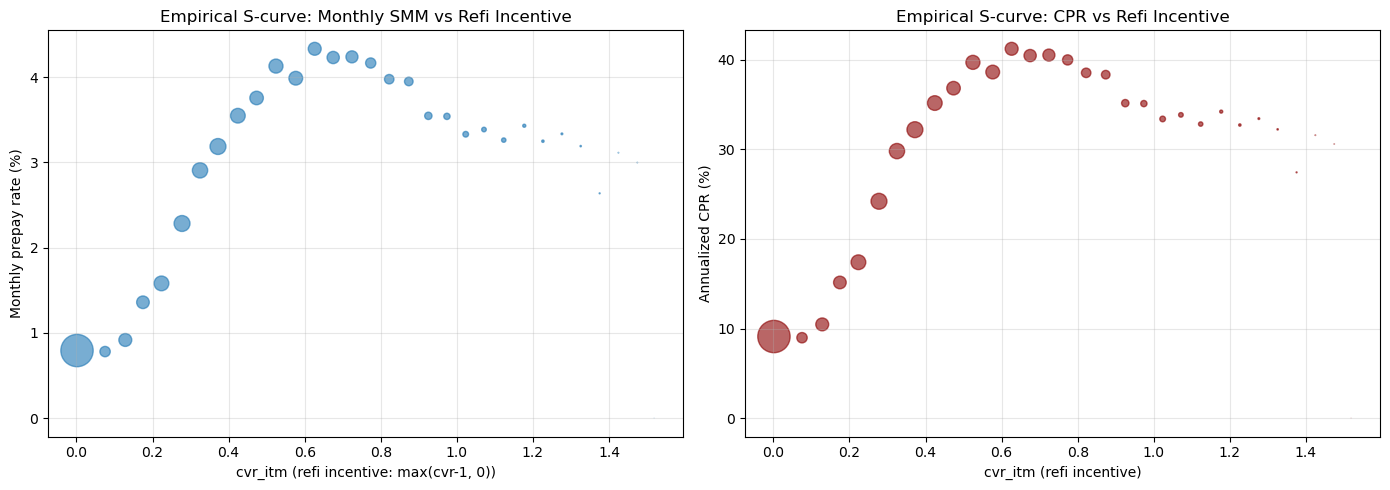


Done in 2.2s


In [75]:
import matplotlib.pyplot as plt
import time
start = time.time()

# Build monthly prepayment data (all valid rows)
prepay_df = df[['cvr_itm', 'event_prepaid', 'loan_age', 'fico', 'current_ltv', 'spread']].copy()
prepay_df = prepay_df.dropna(subset=['cvr_itm', 'fico', 'current_ltv', 'spread'])

print(f"Monthly observations: {len(prepay_df):,}")
print(f"Prepay events: {prepay_df['event_prepaid'].sum():,}")
print(f"Monthly prepay rate: {prepay_df['event_prepaid'].mean()*100:.3f}%")

# Bin observations by cvr_itm and compute empirical prepayment rate in each bin
prepay_df['cvr_itm_bin'] = pd.cut(prepay_df['cvr_itm'], 
                                    bins=np.arange(0, 1.6, 0.05),
                                    include_lowest=True)

bin_stats = prepay_df.groupby('cvr_itm_bin', observed=True).agg(
    bin_center=('cvr_itm', 'mean'),
    n_obs=('event_prepaid', 'size'),
    prepay_rate=('event_prepaid', 'mean')
).reset_index()

# Annualize the monthly rate (CPR = Conditional Prepayment Rate, standard industry metric)
# CPR = 1 - (1 - SMM)^12, where SMM is single monthly mortality (our prepay_rate)
bin_stats['cpr'] = 1 - (1 - bin_stats['prepay_rate'])**12

print("\n--- Empirical S-curve (CPR by cvr_itm bucket) ---")
print(bin_stats[['bin_center', 'n_obs', 'prepay_rate', 'cpr']].to_string(index=False))

# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(bin_stats['bin_center'], bin_stats['prepay_rate']*100, 
                s=bin_stats['n_obs']/5000, alpha=0.6)
axes[0].set_xlabel('cvr_itm (refi incentive: max(cvr-1, 0))')
axes[0].set_ylabel('Monthly prepay rate (%)')
axes[0].set_title('Empirical S-curve: Monthly SMM vs Refi Incentive')
axes[0].grid(alpha=0.3)

axes[1].scatter(bin_stats['bin_center'], bin_stats['cpr']*100,
                s=bin_stats['n_obs']/5000, alpha=0.6, color='darkred')
axes[1].set_xlabel('cvr_itm (refi incentive)')
axes[1].set_ylabel('Annualized CPR (%)')
axes[1].set_title('Empirical S-curve: CPR vs Refi Incentive')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('empirical_s_curve.png', dpi=120, bbox_inches='tight')
plt.show()

print(f"\nDone in {time.time()-start:.1f}s")

Fitting S-curve + burnout model...
Optimization terminated successfully.
         Current function value: 114004.368450
         Iterations: 358
         Function evaluations: 599

Fit done in 13.4s
Converged: True
Final log-likelihood: -114004.37

Estimated parameters:
  Turnover rate (baseline monthly SMM):  0.766%
  Refi amplitude (monthly SMM at peak):  2.822%
  S-curve slope:                         17.67
  S-curve center (cvr_itm):              0.269
  Burnout decay:                         -0.0103

Evaluating on 2019Q1 held-out test set...
S-curve model AUC (held-out):  0.6592


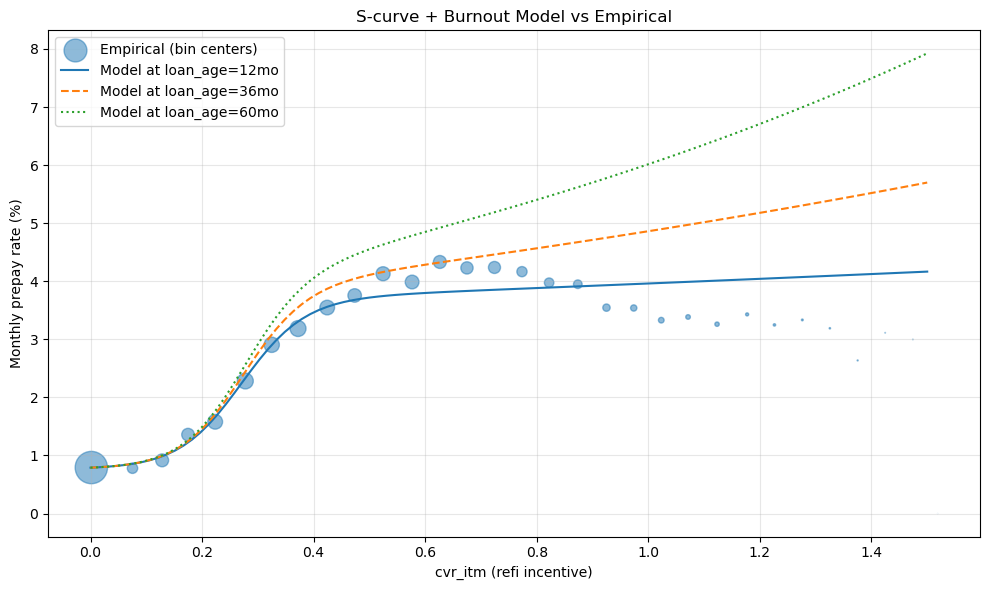


Total time: 15.5s


In [77]:
from scipy.optimize import minimize
import time
start = time.time()

# Build the S-curve + burnout model
# P(prepay | features) = turnover + refi_amplitude × S_curve(cvr_itm) × (1 - burnout)
# 
# S_curve(x) = 1 / (1 + exp(-slope × (x - center))) → logistic S-curve, bounded [0, 1]
# burnout = 1 - exp(-decay × loan_age × cvr_itm)  → burns out with age × incentive

# Downsample for faster optimization (1M rows is plenty for fitting 5 params)
np.random.seed(7)
fit_df = prepay_df.sample(n=1_000_000, random_state=7).copy()
fit_df = fit_df.reset_index(drop=True)

y = fit_df['event_prepaid'].values.astype(np.float64)
cvr_itm = fit_df['cvr_itm'].values.astype(np.float64)
age = fit_df['loan_age'].fillna(0).values.astype(np.float64)

# Define the model function: monthly prepay probability
def model_pred(params, cvr, age):
    turnover, refi_amp, slope, center, burnout_decay = params
    s_curve = 1.0 / (1.0 + np.exp(-slope * (cvr - center)))
    burnout = 1.0 - np.exp(-burnout_decay * age * cvr)
    prob = turnover + refi_amp * s_curve * (1.0 - burnout)
    # Clip to valid probability range
    return np.clip(prob, 1e-9, 1.0 - 1e-9)

# Negative log-likelihood for Bernoulli outcomes
def neg_log_lik(params, y, cvr, age):
    p = model_pred(params, cvr, age)
    ll = y * np.log(p) + (1 - y) * np.log(1 - p)
    return -np.sum(ll)

# Initial parameter guesses based on the empirical plot
initial = [
    0.008,    # turnover ~ 0.8% monthly (from plot at cvr_itm=0)
    0.040,    # refi_amp ~ 4% peak above baseline
    10.0,     # slope (steepness of S-curve)
    0.3,      # center (where S-curve crosses midpoint)
    0.01      # burnout_decay (how fast pool burns out)
]

print("Fitting S-curve + burnout model...")
result = minimize(
    neg_log_lik,
    initial,
    args=(y, cvr_itm, age),
    method='Nelder-Mead',
    options={'maxiter': 5000, 'xatol': 1e-7, 'fatol': 1e-7, 'disp': True}
)

print(f"\nFit done in {time.time()-start:.1f}s")
print(f"Converged: {result.success}")
print(f"Final log-likelihood: {-result.fun:.2f}")
print(f"\nEstimated parameters:")
print(f"  Turnover rate (baseline monthly SMM):  {result.x[0]*100:.3f}%")
print(f"  Refi amplitude (monthly SMM at peak):  {result.x[1]*100:.3f}%")
print(f"  S-curve slope:                         {result.x[2]:.2f}")
print(f"  S-curve center (cvr_itm):              {result.x[3]:.3f}")
print(f"  Burnout decay:                         {result.x[4]:.4f}")

# Predict on held-out test (reuse the same train_mask / test_mask from before)
print("\nEvaluating on 2019Q1 held-out test set...")
X_test_prepay = df.loc[~train_mask & df['cvr_itm'].notna() & df['loan_age'].notna(), 
                       ['cvr_itm', 'loan_age', 'event_prepaid']].copy()
y_test_prepay = X_test_prepay['event_prepaid'].values
p_test = model_pred(result.x, 
                    X_test_prepay['cvr_itm'].values.astype(np.float64),
                    X_test_prepay['loan_age'].fillna(0).values.astype(np.float64))
auc_scurve = roc_auc_score(y_test_prepay, p_test)
print(f"S-curve model AUC (held-out):  {auc_scurve:.4f}")

# Save
scurve_params = {
    'turnover': result.x[0],
    'refi_amp': result.x[1],
    'slope': result.x[2],
    'center': result.x[3],
    'burnout_decay': result.x[4],
    'auc': auc_scurve
}
import pickle
with open('scurve_prepay_final.pkl', 'wb') as f:
    pickle.dump(scurve_params, f)

# Plot model vs empirical
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(bin_stats['bin_center'], bin_stats['prepay_rate']*100,
           s=bin_stats['n_obs']/5000, alpha=0.5, label='Empirical (bin centers)')
# Predict across cvr_itm grid at two representative loan ages
cvr_grid = np.linspace(0, 1.5, 100)
for age_val, linestyle in [(12, '-'), (36, '--'), (60, ':')]:
    ages = np.full_like(cvr_grid, age_val)
    preds = model_pred(result.x, cvr_grid, ages)
    ax.plot(cvr_grid, preds*100, linestyle, label=f'Model at loan_age={age_val}mo')
ax.set_xlabel('cvr_itm (refi incentive)')
ax.set_ylabel('Monthly prepay rate (%)')
ax.set_title('S-curve + Burnout Model vs Empirical')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('scurve_fit.png', dpi=120, bbox_inches='tight')
plt.show()

print(f"\nTotal time: {time.time()-start:.1f}s")

In [79]:
# Save S-curve parameters and a summary of all models so far
import pickle
import json

models_summary = {
    'default_models': {
        'cox_v1':    {'concordance': float(cph_v1.concordance_index_), 'aic': float(cph_v1.AIC_partial_)},
        'cox_v2':    {'concordance': float(cph_v2.concordance_index_), 'aic': float(cph_v2.AIC_partial_)},
        'cox_v3':    {'concordance': float(cph_v3.concordance_index_), 'aic': float(cph_v3.AIC_partial_)},
        'logit_final': {'auc_2019Q1_holdout': float(auc_final)}
    },
    'prepay_models': {
        'cox_pm_v1':  {'concordance': float(cph_pm_v1.concordance_index_), 'aic': float(cph_pm_v1.AIC_partial_)},
        'cox_pm_v2':  {'concordance': float(cph_pm_v2.concordance_index_), 'aic': float(cph_pm_v2.AIC_partial_)},
        'cox_pm_v3':  {'concordance': float(cph_pm_v3.concordance_index_), 'aic': float(cph_pm_v3.AIC_partial_)},
        'cox_pm_v3b': {'concordance': float(cph_pm_v3b.concordance_index_), 'aic': float(cph_pm_v3b.AIC_partial_)},
        'scurve':     {'auc_2019Q1_holdout': float(auc_scurve), 'params': scurve_params}
    }
}

with open('models_summary_Q1.json', 'w') as f:
    json.dump(models_summary, f, indent=2, default=str)

print("Saved models_summary_Q1.json")
print("\n--- Current leaderboard (2019Q1 held-out) ---")
print(f"DEFAULT:")
print(f"  Cox v1:         concordance = {cph_v1.concordance_index_:.4f}")
print(f"  Cox v2:         concordance = {cph_v2.concordance_index_:.4f}")
print(f"  Cox v3:         concordance = {cph_v3.concordance_index_:.4f}")
print(f"  Logistic final: AUC         = {auc_final:.4f}")
print(f"\nPREPAY:")
print(f"  Cox pm v1:      concordance = {cph_pm_v1.concordance_index_:.4f}")
print(f"  Cox pm v2:      concordance = {cph_pm_v2.concordance_index_:.4f}")
print(f"  Cox pm v3:      concordance = {cph_pm_v3.concordance_index_:.4f}")
print(f"  Cox pm v3b:     concordance = {cph_pm_v3b.concordance_index_:.4f}")
print(f"  S-curve:        AUC         = {auc_scurve:.4f}")

Saved models_summary_Q1.json

--- Current leaderboard (2019Q1 held-out) ---
DEFAULT:
  Cox v1:         concordance = 0.7396
  Cox v2:         concordance = 0.7642
  Cox v3:         concordance = 0.8729
  Logistic final: AUC         = 0.8915

PREPAY:
  Cox pm v1:      concordance = 0.5752
  Cox pm v2:      concordance = 0.5753
  Cox pm v3:      concordance = 0.6269
  Cox pm v3b:     concordance = 0.7127
  S-curve:        AUC         = 0.6592


In [81]:
import time

file_path_q2 = "2019Q2.csv"  

# Verify file exists
import os
print(f"File exists: {os.path.exists(file_path_q2)}")
print(f"Size: {os.path.getsize(file_path_q2) / 1024**3:.2f} GB")

# Same column mapping as Q1
cols_to_load = {
    1:  'loan_id',
    2:  'rpt_period',
    7:  'orig_rate',
    9:  'orig_upb',
    11: 'current_upb',
    13: 'orig_date',
    15: 'loan_age',
    19: 'oltv',
    22: 'dti',
    23: 'fico',
    27: 'prop_type',
    29: 'occ_status',
    30: 'state',
    31: 'msa',
    39: 'dlq_status',
    41: 'mod_flag',
    43: 'zero_bal_code',
}

col_positions = sorted(cols_to_load.keys())
col_names = [cols_to_load[p] for p in col_positions]

dtypes = {
    'loan_id':       'int64',
    'rpt_period':    'float32',
    'orig_rate':     'float32',
    'orig_upb':      'float32',
    'current_upb':   'float32',
    'orig_date':     'float32',
    'loan_age':      'float32',
    'oltv':          'float32',
    'dti':           'float32',
    'fico':          'float32',
    'prop_type':     'category',
    'occ_status':    'category',
    'state':         'category',
    'msa':           'float32',
    'dlq_status':    'string',
    'mod_flag':      'category',
    'zero_bal_code': 'float32',
}

chunk_size = 300_000
chunks = []
start = time.time()
total_rows = 0

print("\nLoading 2019Q2 in chunks...")
print("-" * 60)

for i, chunk in enumerate(pd.read_csv(
    file_path_q2,
    sep="|",
    header=None,
    usecols=col_positions,
    names=col_names,
    dtype=dtypes,
    chunksize=chunk_size,
    low_memory=False
)):
    chunks.append(chunk)
    total_rows += len(chunk)
    elapsed = time.time() - start
    print(f"Chunk {i+1:2d} | rows: {total_rows:>10,} | time: {elapsed:>4.0f}s")

print("-" * 60)
print("Concatenating chunks...")
df_q2 = pd.concat(chunks, ignore_index=True)
del chunks
import gc
gc.collect()

print(f"\nShape: {df_q2.shape}")
print(f"Memory: {df_q2.memory_usage(deep=True).sum() / 1024**2:.0f} MB")
print(f"Unique loans: {df_q2['loan_id'].nunique():,}")
print(f"Total time: {(time.time() - start)/60:.1f} min")

df_q2.head()

File exists: True
Size: 3.85 GB

Loading 2019Q2 in chunks...
------------------------------------------------------------
Chunk  1 | rows:    300,000 | time:    1s
Chunk  2 | rows:    600,000 | time:    1s
Chunk  3 | rows:    900,000 | time:    2s
Chunk  4 | rows:  1,200,000 | time:    3s
Chunk  5 | rows:  1,500,000 | time:    3s
Chunk  6 | rows:  1,800,000 | time:    4s
Chunk  7 | rows:  2,100,000 | time:    4s
Chunk  8 | rows:  2,400,000 | time:    5s
Chunk  9 | rows:  2,700,000 | time:    6s
Chunk 10 | rows:  3,000,000 | time:    6s
Chunk 11 | rows:  3,300,000 | time:    7s
Chunk 12 | rows:  3,600,000 | time:    7s
Chunk 13 | rows:  3,900,000 | time:    8s
Chunk 14 | rows:  4,200,000 | time:    9s
Chunk 15 | rows:  4,500,000 | time:    9s
Chunk 16 | rows:  4,800,000 | time:   10s
Chunk 17 | rows:  5,100,000 | time:   10s
Chunk 18 | rows:  5,400,000 | time:   11s
Chunk 19 | rows:  5,700,000 | time:   12s
Chunk 20 | rows:  6,000,000 | time:   12s
Chunk 21 | rows:  6,300,000 | time:   

,loan_id,rpt_period,orig_rate,orig_upb,current_upb,orig_date,loan_age,oltv,dti,fico,prop_type,occ_status,state,msa,dlq_status,mod_flag,zero_bal_code
0,100001140856,62019.0,4.875,154000.0,0.0,42019.0,1.0,80.0,38.0,693.0,SF,P,TX,47020.0,00,N,NaN
1,100001140856,72019.0,4.875,154000.0,0.0,42019.0,2.0,80.0,38.0,693.0,SF,P,TX,47020.0,00,N,NaN
2,100001140856,82019.0,4.875,154000.0,0.0,42019.0,3.0,80.0,38.0,693.0,SF,P,TX,47020.0,00,N,NaN
3,100001140856,92019.0,4.875,154000.0,0.0,42019.0,4.0,80.0,38.0,693.0,SF,P,TX,47020.0,00,N,NaN
4,100001140856,102019.0,4.875,154000.0,0.0,42019.0,5.0,80.0,38.0,693.0,SF,P,TX,47020.0,00,N,NaN


In [83]:
import time
start = time.time()

print("="*60)
print("PREPROCESSING 2019Q2 (replicating Q1 pipeline)")
print("="*60)

# === Step 1: Classify each loan's outcome ===
print("\nStep 1/7: Classifying loan outcomes...")
loan_terminal_q2 = df_q2.groupby('loan_id').agg(
    last_zbc=('zero_bal_code', 'max'),
    has_mod=('mod_flag', lambda x: (x == 'Y').any()),
    n_months=('loan_id', 'size')
).reset_index()

def classify(row):
    zbc = row['last_zbc']
    has_mod = row['has_mod']
    if zbc in [2, 3, 9, 15]:
        return 'default'
    elif zbc == 1:
        return 'prepaid'
    elif zbc in [6, 16]:
        return 'censored'
    elif has_mod:
        return 'censored'
    else:
        return 'current'

loan_terminal_q2['status'] = loan_terminal_q2.apply(classify, axis=1)
print(f"  Status distribution:\n{loan_terminal_q2['status'].value_counts()}")

# === Step 2: Merge status and create event indicators ===
print("\nStep 2/7: Merging status and creating events...")
df_q2 = df_q2.merge(loan_terminal_q2[['loan_id', 'status']], on='loan_id', how='left')
df_q2['event_default'] = df_q2['zero_bal_code'].isin([2, 3, 9, 15]).astype('int8')
df_q2['event_prepaid'] = (df_q2['zero_bal_code'] == 1).astype('int8')

# Fix loan_age NaN on termination rows
df_q2['max_age'] = df_q2.groupby('loan_id')['loan_age'].transform('max')
mask_term = df_q2['loan_age'].isna()
df_q2.loc[mask_term, 'loan_age'] = df_q2.loc[mask_term, 'max_age'] + 1
df_q2 = df_q2.drop(columns=['max_age'])

df_q2['start'] = df_q2['loan_age']
df_q2['end']   = df_q2['loan_age'] + 1

print(f"  Default events: {df_q2['event_default'].sum():,}")
print(f"  Prepaid events: {df_q2['event_prepaid'].sum():,}")

# === Step 3: Fill early-month UPB blanking ===
print("\nStep 3/7: Filling early-month UPB...")
mask_early = (df_q2['loan_age'] <= 6) & (df_q2['current_upb'] == 0)
df_q2.loc[mask_early, 'current_upb'] = df_q2.loc[mask_early, 'orig_upb']
print(f"  Filled {mask_early.sum():,} rows")

# === Step 4: dlq_numeric, drop missing, create implied home value ===
print("\nStep 4/7: Cleaning modeling variables...")
df_q2['dlq_numeric'] = pd.to_numeric(df_q2['dlq_status'], errors='coerce')
rows_before = len(df_q2)
df_q2 = df_q2.dropna(subset=['fico', 'oltv', 'dti']).reset_index(drop=True)
print(f"  Dropped {rows_before - len(df_q2):,} rows with missing fico/oltv/dti")

df_q2['implied_home_value'] = df_q2['orig_upb'] / df_q2['oltv'] * 100

# === Step 5: Compute usable_upb (forward-fill) and current_ltv ===
print("\nStep 5/7: Building current_ltv (leak-free)...")
df_q2 = df_q2.sort_values(['loan_id', 'loan_age']).reset_index(drop=True)
df_q2['usable_upb'] = df_q2['current_upb'].where(df_q2['current_upb'] > 0, np.nan)
df_q2['usable_upb'] = df_q2.groupby('loan_id')['usable_upb'].ffill()
df_q2['current_ltv'] = df_q2['usable_upb'] / df_q2['implied_home_value'] * 100
print(f"  current_ltv NaN rows: {df_q2['current_ltv'].isna().sum():,}")

# === Step 6: Merge origination spread (from monthly_rates we built earlier) ===
print("\nStep 6/7: Computing spread and cvr...")
# Use the monthly_rates_full table we built for Q1
df_q2 = df_q2.merge(
    monthly_rates_full[['rpt_period_key', 'current_natl_rate']].rename(columns={'rpt_period_key': 'orig_date_key'}),
    left_on='orig_date', right_on='orig_date_key', how='left'
)
df_q2 = df_q2.drop(columns=['orig_date_key'])
df_q2 = df_q2.rename(columns={'current_natl_rate': 'orig_natl_rate'})
df_q2['spread'] = df_q2['orig_rate'] - df_q2['orig_natl_rate']

# Compute cvr = orig_rate / current_natl_rate (separate merge on rpt_period)
df_q2 = df_q2.merge(
    monthly_rates_full[['rpt_period_key', 'current_natl_rate']],
    left_on='rpt_period', right_on='rpt_period_key', how='left'
)
df_q2 = df_q2.drop(columns=['rpt_period_key'])
df_q2['cvr'] = df_q2['orig_rate'] / df_q2['current_natl_rate']
df_q2['cvr_itm'] = (df_q2['cvr'] - 1).clip(lower=0)
df_q2['cvr_otm'] = (1 - df_q2['cvr']).clip(lower=0)

print(f"  Spread range: [{df_q2['spread'].min():.3f}, {df_q2['spread'].max():.3f}]")
print(f"  cvr range:    [{df_q2['cvr'].min():.3f}, {df_q2['cvr'].max():.3f}]")

# === Step 7: Save ===
print("\nStep 7/7: Saving Q2 panel to Parquet...")
df_q2.to_parquet("2019Q2_panel.parquet", compression="snappy")

print(f"\n{'='*60}")
print(f"TOTAL TIME: {(time.time()-start)/60:.1f} min")
print(f"Rows: {len(df_q2):,}")
print(f"Loans: {df_q2['loan_id'].nunique():,}")
print(f"Default events: {df_q2['event_default'].sum():,}")
print(f"Prepaid events: {df_q2['event_prepaid'].sum():,}")
print(f"Memory: {df_q2.memory_usage(deep=True).sum() / 1024**2:.0f} MB")
print(f"{'='*60}")

PREPROCESSING 2019Q2 (replicating Q1 pipeline)

Step 1/7: Classifying loan outcomes...
  Status distribution:
status
prepaid     314243
current      88188
censored      4402
default        556
Name: count, dtype: int64

Step 2/7: Merging status and creating events...
  Default events: 556
  Prepaid events: 314,243

Step 3/7: Filling early-month UPB...
  Filled 2,403,133 rows

Step 4/7: Cleaning modeling variables...
  Dropped 20,265 rows with missing fico/oltv/dti

Step 5/7: Building current_ltv (leak-free)...
  current_ltv NaN rows: 9,255

Step 6/7: Computing spread and cvr...
  Spread range: [-1.515, 2.732]
  cvr range:    [0.361, 2.568]

Step 7/7: Saving Q2 panel to Parquet...

TOTAL TIME: 0.5 min
Rows: 13,825,380
Loans: 406,893
Default events: 549
Prepaid events: 313,881
Memory: 3850 MB


In [85]:
import time
from sklearn.metrics import roc_auc_score, roc_curve
import matplotlib.pyplot as plt
start = time.time()

print("="*70)
print("OUT-OF-SAMPLE VALIDATION: 2019Q2")
print("="*70)

# ==========================================
# 1. Cox v3 (default) on Q2
# ==========================================
print("\n--- 1. Cox v3 default model on Q2 ---")
q2_cox_def = df_q2[['start', 'end', 'event_default', 
                     'oltv', 'fico', 'spread', 'cvr', 'current_ltv']].copy()
q2_cox_def = q2_cox_def.dropna(subset=['spread', 'cvr', 'current_ltv'])
q2_cox_def = q2_cox_def[q2_cox_def['end'] > q2_cox_def['start']].reset_index(drop=True)
print(f"  Rows: {len(q2_cox_def):,} | Events: {q2_cox_def['event_default'].sum():,}")

# Use predict_partial_hazard to get risk score per row
risk_cox_def = cph_v3.predict_partial_hazard(q2_cox_def).values
# Need one score per loan for AUC — take the MAX partial hazard a loan ever had
q2_cox_def['risk'] = risk_cox_def
q2_cox_def['loan_id'] = df_q2.loc[q2_cox_def.index, 'loan_id'].values if False else None  # fallback
# Simpler: compute AUC at the row level using event as binary
auc_cox_v3_q2 = roc_auc_score(q2_cox_def['event_default'], risk_cox_def)
print(f"  AUC on Q2: {auc_cox_v3_q2:.4f}")

# ==========================================
# 2. Logistic default (Fix A) on Q2
# ==========================================
print("\n--- 2. Logistic default model on Q2 ---")
q2_logit = df_q2[['fico', 'spread', 'cvr_itm', 'cvr_otm', 'current_ltv', 'loan_age', 'event_default']].copy()
q2_logit = q2_logit.dropna()
print(f"  Rows: {len(q2_logit):,} | Events: {q2_logit['event_default'].sum():,}")

X_q2_logit = scaler_final.transform(q2_logit[feat_cols_final].values)
y_q2_logit = q2_logit['event_default'].values
p_q2_logit = logit_default_final.predict_proba(X_q2_logit)[:, 1]
auc_logit_q2 = roc_auc_score(y_q2_logit, p_q2_logit)
print(f"  AUC on Q2: {auc_logit_q2:.4f}")

# ==========================================
# 3. Cox pm v3b (prepay) on Q2
# ==========================================
print("\n--- 3. Cox v3b prepayment model on Q2 ---")
q2_cox_pp = df_q2[['start', 'end', 'event_prepaid',
                    'oltv', 'fico', 'spread', 'cvr_itm', 'cvr_otm', 'current_ltv']].copy()
q2_cox_pp = q2_cox_pp.dropna(subset=['spread', 'cvr_itm', 'cvr_otm', 'current_ltv'])
q2_cox_pp = q2_cox_pp[q2_cox_pp['end'] > q2_cox_pp['start']].reset_index(drop=True)
print(f"  Rows: {len(q2_cox_pp):,} | Events: {q2_cox_pp['event_prepaid'].sum():,}")

risk_cox_pp = cph_pm_v3b.predict_partial_hazard(q2_cox_pp).values
auc_cox_pp_q2 = roc_auc_score(q2_cox_pp['event_prepaid'], risk_cox_pp)
print(f"  AUC on Q2: {auc_cox_pp_q2:.4f}")

# ==========================================
# 4. S-curve prepayment model on Q2
# ==========================================
print("\n--- 4. S-curve prepayment model on Q2 ---")
q2_scurve = df_q2[['cvr_itm', 'loan_age', 'event_prepaid']].copy()
q2_scurve = q2_scurve.dropna()
print(f"  Rows: {len(q2_scurve):,} | Events: {q2_scurve['event_prepaid'].sum():,}")

# Apply the same model_pred function from before using saved params
def model_pred_saved(params_dict, cvr, age):
    s_curve = 1.0 / (1.0 + np.exp(-params_dict['slope'] * (cvr - params_dict['center'])))
    burnout = 1.0 - np.exp(-params_dict['burnout_decay'] * age * cvr)
    prob = params_dict['turnover'] + params_dict['refi_amp'] * s_curve * (1.0 - burnout)
    return np.clip(prob, 1e-9, 1.0 - 1e-9)

p_q2_scurve = model_pred_saved(
    scurve_params,
    q2_scurve['cvr_itm'].values.astype(np.float64),
    q2_scurve['loan_age'].values.astype(np.float64)
)
auc_scurve_q2 = roc_auc_score(q2_scurve['event_prepaid'], p_q2_scurve)
print(f"  AUC on Q2: {auc_scurve_q2:.4f}")

# ==========================================
# Final comparison table
# ==========================================
print("\n" + "="*70)
print("FINAL OUT-OF-SAMPLE RESULTS (trained on Q1, tested on Q2)")
print("="*70)
print(f"\n{'Model':<35} {'Q1 train':>12} {'Q2 OOS':>12} {'Delta':>8}")
print("-"*70)
print("DEFAULT MODELS")
print(f"  {'Cox v3 (academic)':<33} {cph_v3.concordance_index_:>12.4f} {auc_cox_v3_q2:>12.4f} {auc_cox_v3_q2 - cph_v3.concordance_index_:>+8.4f}")
print(f"  {'Logistic (industry)':<33} {auc_final:>12.4f} {auc_logit_q2:>12.4f} {auc_logit_q2 - auc_final:>+8.4f}")
print()
print("PREPAYMENT MODELS")
print(f"  {'Cox v3b (academic)':<33} {cph_pm_v3b.concordance_index_:>12.4f} {auc_cox_pp_q2:>12.4f} {auc_cox_pp_q2 - cph_pm_v3b.concordance_index_:>+8.4f}")
print(f"  {'S-curve (industry)':<33} {auc_scurve:>12.4f} {auc_scurve_q2:>12.4f} {auc_scurve_q2 - auc_scurve:>+8.4f}")

# Save results
final_results = {
    'default': {
        'cox_v3': {'q1_concordance': float(cph_v3.concordance_index_), 'q2_auc': float(auc_cox_v3_q2)},
        'logistic': {'q1_auc': float(auc_final), 'q2_auc': float(auc_logit_q2)}
    },
    'prepay': {
        'cox_v3b': {'q1_concordance': float(cph_pm_v3b.concordance_index_), 'q2_auc': float(auc_cox_pp_q2)},
        'scurve': {'q1_auc': float(auc_scurve), 'q2_auc': float(auc_scurve_q2)}
    }
}

import json
with open('final_results.json', 'w') as f:
    json.dump(final_results, f, indent=2)

print(f"\nTotal time: {time.time()-start:.1f}s")
print("Results saved to final_results.json")

OUT-OF-SAMPLE VALIDATION: 2019Q2

--- 1. Cox v3 default model on Q2 ---
  Rows: 12,963,850 | Events: 456
  AUC on Q2: 0.7866

--- 2. Logistic default model on Q2 ---
  Rows: 12,963,850 | Events: 456
  AUC on Q2: 0.8762

--- 3. Cox v3b prepayment model on Q2 ---
  Rows: 12,963,850 | Events: 308,362
  AUC on Q2: 0.6489

--- 4. S-curve prepayment model on Q2 ---
  Rows: 12,974,063 | Events: 308,555
  AUC on Q2: 0.6656

FINAL OUT-OF-SAMPLE RESULTS (trained on Q1, tested on Q2)

Model                                   Q1 train       Q2 OOS    Delta
----------------------------------------------------------------------
DEFAULT MODELS
  Cox v3 (academic)                       0.8729       0.7866  -0.0863
  Logistic (industry)                     0.8915       0.8762  -0.0152

PREPAYMENT MODELS
  Cox v3b (academic)                      0.7127       0.6489  -0.0638
  S-curve (industry)                      0.6592       0.6656  +0.0065

Total time: 24.0s
Results saved to final_results.json
